# EDA - PetFinder Adoption Prediction

Análisis exploratorio del dataset de entrenamiento de la competencia de Kaggle [PetFinder.my Adoption Prediction](https://www.kaggle.com/c/petfinder-adoption-prediction).

**Objetivo:** Comprender la estructura y distribución de los datos como punto de partida para el entrenamiento de un modelo predictivo de `AdoptionSpeed`, una variable objetivo ordinal con clases de 0 a 4, donde valores más bajos indican adopciones más rápidas.

**Estructura del análisis:**
1. Carga y limpieza inicial
2. Análisis univariado
3. Análisis bivariado (relación con el target)
4. Análisis multivariado

## 1. Carga y limpieza inicial

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from wordcloud import WordCloud

%matplotlib inline
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = [12.0, 6.0]
sns.set_style('whitegrid')

In [3]:
# Rutas
BASE_PATH = "../input/petfinder-adoption-prediction/"

train = pd.read_csv(BASE_PATH + 'train/train.csv')
breeds = pd.read_csv(BASE_PATH + 'breed_labels.csv')
colors = pd.read_csv(BASE_PATH + 'color_labels.csv')
states = pd.read_csv(BASE_PATH + 'state_labels.csv')

print(f'train shape: {train.shape}')
train.head()

train shape: (14993, 24)


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,1,1,1,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,1,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


### 1.1 Diccionario de variables

| Variable | Descripción |
|---|---|
| `PetID` | ID único del perfil de la mascota |
| `AdoptionSpeed` | **Target**: velocidad de adopción (0=mismo día, 1=1ª semana, 2=1er mes, 3=2do-3er mes, 4=no adoptado en 100 días) |
| `Type` | Tipo de animal (1=Perro, 2=Gato) |
| `Name` | Nombre de la mascota |
| `Age` | Edad en meses al momento del listado |
| `Breed1` | Raza primaria |
| `Breed2` | Raza secundaria (si es mestizo) |
| `Gender` | Género (1=Macho, 2=Hembra, 3=Mixto) |
| `Color1/2/3` | Colores de la mascota |
| `MaturitySize` | Tamaño al madurar (1=Pequeño, 2=Mediano, 3=Grande, 4=Extra Grande, 0=No especificado) |
| `FurLength` | Largo del pelo (1=Corto, 2=Mediano, 3=Largo, 0=No especificado) |
| `Vaccinated` | Vacunado (1=Sí, 2=No, 3=No sabe) |
| `Dewormed` | Desparasitado (1=Sí, 2=No, 3=No sabe) |
| `Sterilized` | Esterilizado (1=Sí, 2=No, 3=No sabe) |
| `Health` | Condición de salud (1=Sano, 2=Lesión leve, 3=Lesión grave, 0=No especificado) |
| `Quantity` | Cantidad de mascotas en el perfil |
| `Fee` | Tarifa de adopción (0=gratis) |
| `State` | Estado en Malasia |
| `RescuerID` | ID único del rescatista |
| `VideoAmt` | Cantidad de videos subidos |
| `PhotoAmt` | Cantidad de fotos subidas |
| `Description` | Texto descriptivo del perfil |

In [4]:
# Tipos de datos
train.dtypes

Type               int64
Name              object
Age                int64
Breed1             int64
Breed2             int64
Gender             int64
Color1             int64
Color2             int64
Color3             int64
MaturitySize       int64
FurLength          int64
Vaccinated         int64
Dewormed           int64
Sterilized         int64
Health             int64
Quantity           int64
Fee                int64
State              int64
RescuerID         object
VideoAmt           int64
Description       object
PetID             object
PhotoAmt         float64
AdoptionSpeed      int64
dtype: object

### 1.2 Valores nulos

In [5]:
nulls = train.isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(train) * 100).round(2)
null_df = pd.DataFrame({'Nulos': nulls, 'Porcentaje (%)': nulls_pct})
null_df[null_df['Nulos'] > 0]

,Nulos,Porcentaje (%)
Name,1265,8.44
Description,13,0.09


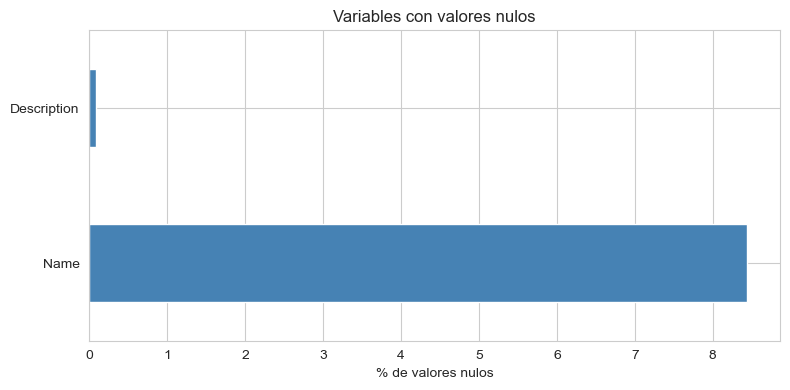

In [6]:
# Visualización de nulos
cols_con_nulos = null_df[null_df['Nulos'] > 0]
plt.figure(figsize=(8, 4))
cols_con_nulos['Porcentaje (%)'].plot(kind='barh', color='steelblue')
plt.xlabel('% de valores nulos')
plt.title('Variables con valores nulos')
plt.tight_layout()
plt.show()

### 1.3 Mapeo de variables categóricas

Convertimos los códigos numéricos a etiquetas descriptivas para facilitar el análisis.

In [7]:
df = train.copy()

# Mapeos según el diccionario de datos
df['Type']         = df['Type'].map({1: 'Perro', 2: 'Gato'})
df['Gender']       = df['Gender'].map({1: 'Macho', 2: 'Hembra', 3: 'Mixto'})
df['MaturitySize'] = df['MaturitySize'].map({0: 'No especif.', 1: 'Pequeño', 2: 'Mediano', 3: 'Grande', 4: 'Extra Grande'})
df['FurLength']    = df['FurLength'].map({0: 'No especif.', 1: 'Corto', 2: 'Mediano', 3: 'Largo'})
df['Vaccinated']   = df['Vaccinated'].map({1: 'Sí', 2: 'No', 3: 'No sabe'})
df['Dewormed']     = df['Dewormed'].map({1: 'Sí', 2: 'No', 3: 'No sabe'})
df['Sterilized']   = df['Sterilized'].map({1: 'Sí', 2: 'No', 3: 'No sabe'})
df['Health']       = df['Health'].map({0: 'No especif.', 1: 'Sano', 2: 'Lesión leve', 3: 'Lesión grave'})

# Unión con labels de colores, razas y estados
color_map = colors.set_index('ColorID')['ColorName'].to_dict()
state_map = states.set_index('StateID')['StateName'].to_dict()
breed_map = breeds.set_index('BreedID')['BreedName'].to_dict()

# Mapeo de variables con labels
df['State']  = df['State'].map(state_map)
df['Color1'] = df['Color1'].map(color_map)
df['Color2'] = df['Color2'].map(color_map)
df['Color3'] = df['Color3'].map(color_map)
df['Breed1'] = df['Breed1'].map(breed_map)
df['Breed2'] = df['Breed2'].map(breed_map)

# Variables derivadas
df['HasName'] = df['Name'].notna() & (df['Name'].str.strip() != '') # tiene nombre
df['IsMixed'] = (train['Breed2'] != 0).astype(int) # es mestizo
df['HasPhoto'] = (df['PhotoAmt'].fillna(0) > 0).astype(int) # tiene foto
df['HasVideo'] = (df['VideoAmt'] > 0).astype(int) # tiene video
df['IsFree'] = (df['Fee'] == 0).astype(int) # adopción gratuita

print('Dataset preparado.')
df.head(3)

Dataset preparado.


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,HasName,IsMixed,HasPhoto,HasVideo,IsFree
0,Gato,Nibble,3,Tabby,NaN,Macho,Black,White,NaN,Pequeño,Corto,No,No,No,Sano,1,100,Selangor,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2,True,0,1,0,0
1,Gato,No Name Yet,1,Domestic Medium Hair,NaN,Macho,Black,Brown,NaN,Mediano,Mediano,No sabe,No sabe,No sabe,Sano,1,0,Kuala Lumpur,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0,True,0,1,0,1
2,Perro,Brisco,1,Mixed Breed,NaN,Macho,Brown,White,NaN,Mediano,Mediano,Sí,Sí,No,Sano,1,0,Selangor,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3,True,0,1,0,1


### 1.4 Estadísticas descriptivas

In [8]:
num_cols = ['Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt']

df[num_cols].describe()

,Age,Quantity,Fee,VideoAmt,PhotoAmt
count,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000
mean,10.452078,1.576069,21.259988,0.056760,3.889215
std,18.155790,1.472477,78.414548,0.346185,3.487810
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,0.000000,0.000000,2.000000
50%,3.000000,1.000000,0.000000,0.000000,3.000000
75%,12.000000,1.000000,0.000000,0.000000,5.000000
max,255.000000,20.000000,3000.000000,8.000000,30.000000


In [9]:
df.describe(include='object')

,Type,Name,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,State,RescuerID,Description,PetID
count,14993,13728,14988,4231,14993,14993,10522,4389,14993,14993,14993,14993,14993,14993,14993,14993,14980,14993
unique,2,9059,175,134,3,7,6,5,4,3,3,3,3,3,14,5595,14031,14993
top,Perro,Baby,Mixed Breed,Mixed Breed,Hembra,Black,White,White,Mediano,Corto,No,Sí,No,Sano,Selangor,fa90fa5b1ee11c86938398b60abc32cb,For Adoption,86e1089a3
freq,8132,66,5927,1727,7277,7427,3438,3221,10305,8808,7227,8397,10077,14478,8714,459,164,1


---
## 2. Análisis Univariado

### 2.1 Variable target: AdoptionSpeed

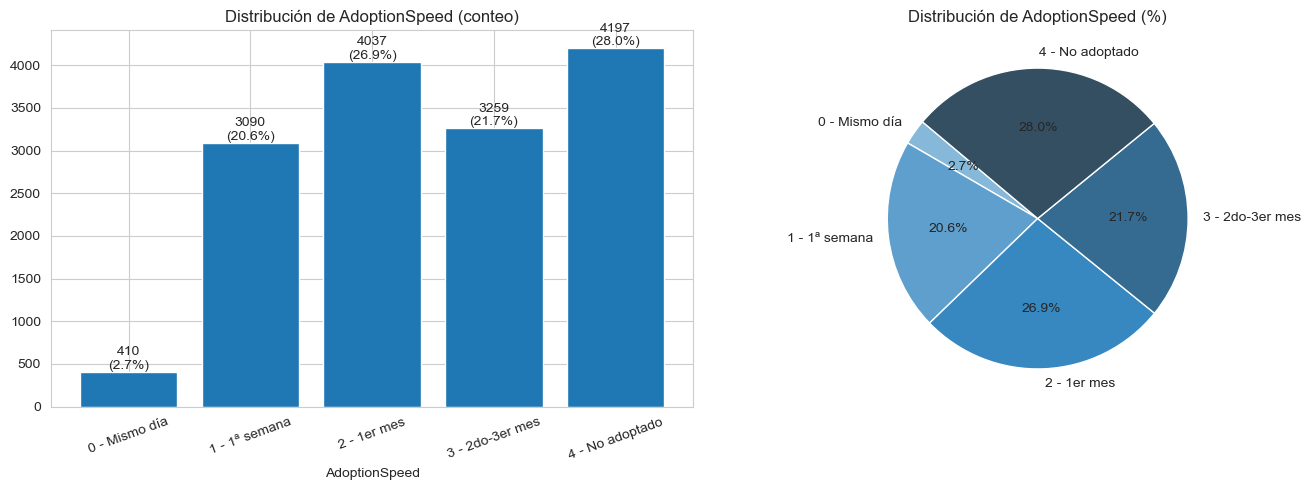

In [10]:
target_labels = {
    0: '0 - Mismo día',
    1: '1 - 1ª semana',
    2: '2 - 1er mes',
    3: '3 - 2do-3er mes',
    4: '4 - No adoptado'
}

counts = df['AdoptionSpeed'].value_counts().sort_index()
pcts   = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(
    [target_labels[i] for i in counts.index],
    counts.values
)

axes[0].set_title('Distribución de AdoptionSpeed (conteo)')
axes[0].set_xlabel('AdoptionSpeed')
axes[0].tick_params(axis='x', rotation=20)

for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{counts.iloc[i]}\n({pcts.iloc[i]:.1f}%)',
        ha='center',
        va='bottom'
    )

axes[1].pie(
    pcts.values,
    labels=[target_labels[i] for i in pcts.index],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Blues_d', len(pcts))
)

axes[1].set_title('Distribución de AdoptionSpeed (%)')

plt.tight_layout()
plt.show()

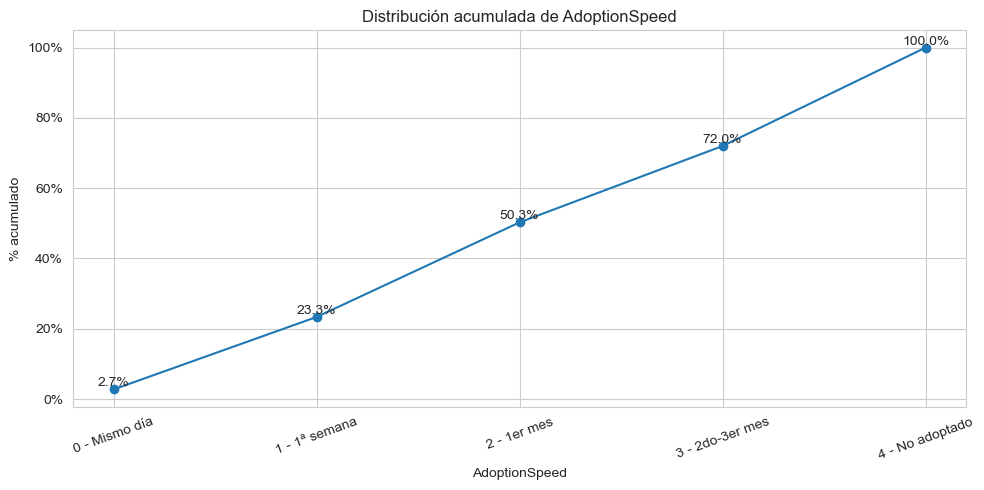

In [11]:
# Distribución acumulada
cum_pct = pcts.cumsum()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    [target_labels[i] for i in cum_pct.index],
    cum_pct.values,
    marker="o"
)

ax.set_title("Distribución acumulada de AdoptionSpeed")
ax.set_xlabel("AdoptionSpeed")
ax.set_ylabel("% acumulado")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', rotation=20)

for i, value in enumerate(cum_pct.values):
    ax.text(
        i,
        value,
        f"{value:.1f}%",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

La distribución de `AdoptionSpeed` muestra que las categorías más frecuentes son la 4 (28%) y la 2 (26.9%), mientras que la adopción inmediata (clase 0) es muy poco frecuente (2.7%).

La distribución acumulada muestra que:
*   Aproximadamente el 50% de las mascotas se adopta dentro del primer mes (clases 0-2).
*   Cerca del 70% se adoptan dentro de los 3 meses (clases 0–3).
*   El 30% restante no se adopta en ese período (clase 4).

### 2.2 Tipo de animal

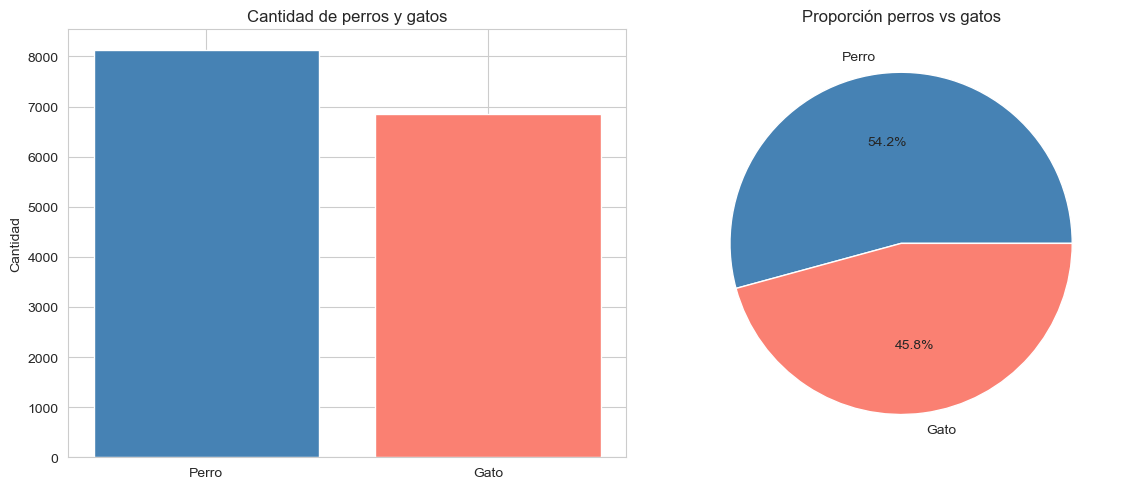

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
vc = df['Type'].value_counts()
axes[0].bar(vc.index, vc.values, color=['steelblue', 'salmon'])
axes[0].set_title('Cantidad de perros y gatos')
axes[0].set_ylabel('Cantidad')

axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%', colors=['steelblue', 'salmon'])
axes[1].set_title('Proporción perros vs gatos')

plt.tight_layout()
plt.show()

### 2.3 Variables numéricas continuas

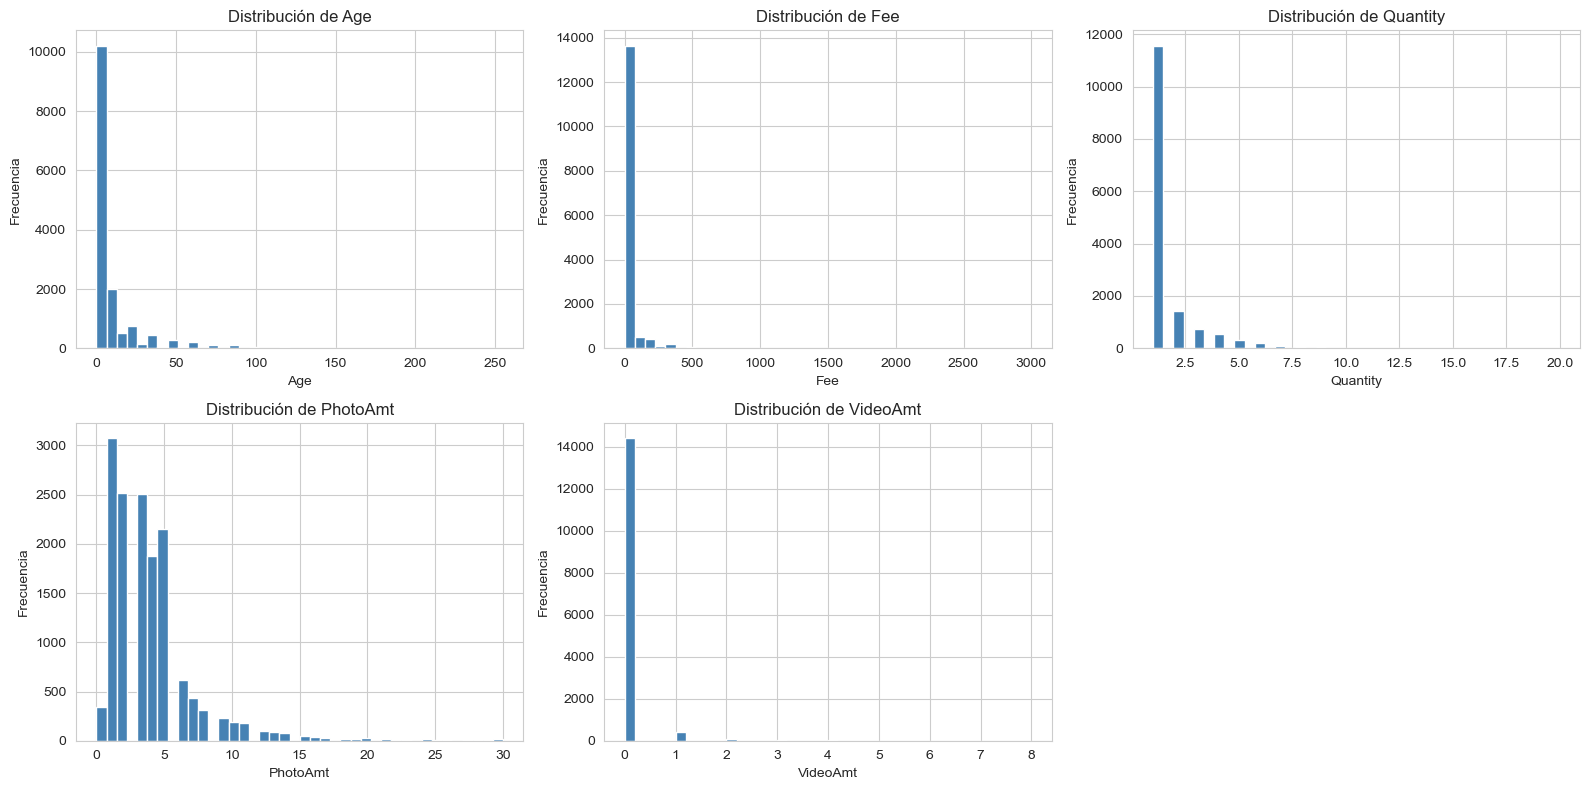

In [13]:
num_cols = ['Age', 'Fee', 'Quantity', 'PhotoAmt', 'VideoAmt']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

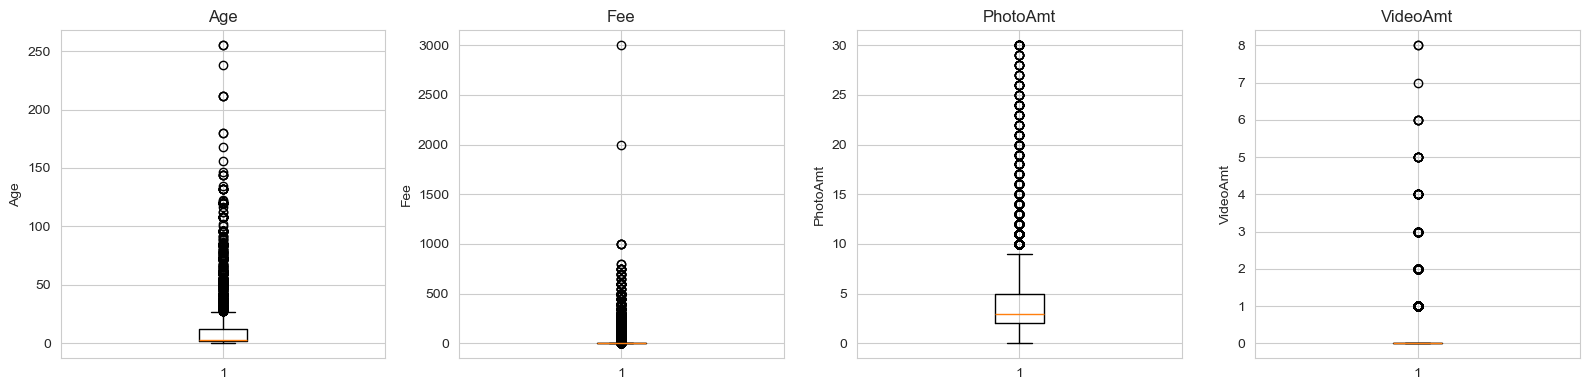

In [14]:
num_cols_plot = ['Age', 'Fee', 'PhotoAmt', 'VideoAmt']

fig, axes = plt.subplots(1, len(num_cols_plot), figsize=(4*len(num_cols_plot), 4))

if len(num_cols_plot) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols_plot):
    ax.boxplot(df[col].dropna(), vert=True)      
    ax.set_title(col)
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

In [15]:
# Estadísticas de variables numéricas clave
df[num_cols].describe().round(2)

,Age,Fee,Quantity,PhotoAmt,VideoAmt
count,14993.00,14993.00,14993.00,14993.00,14993.00
mean,10.45,21.26,1.58,3.89,0.06
std,18.16,78.41,1.47,3.49,0.35
min,0.00,0.00,1.00,0.00,0.00
25%,2.00,0.00,1.00,2.00,0.00
50%,3.00,0.00,1.00,3.00,0.00
75%,12.00,0.00,1.00,5.00,0.00
max,255.00,3000.00,20.00,30.00,8.00


- Las variables presentan fuerte asimetría y presencia de outliers, con concentración en valores bajos.
- La mayoría de las mascotas son jóvenes, lo que puede influir en la adopción.
- Las adopciones son principalmente gratuitas, por lo que Fee tiene poca variabilidad.
- PhotoAmt y DescLength destacan como variables con mayor potencial explicativo.

### 2.4 Variables categóricas

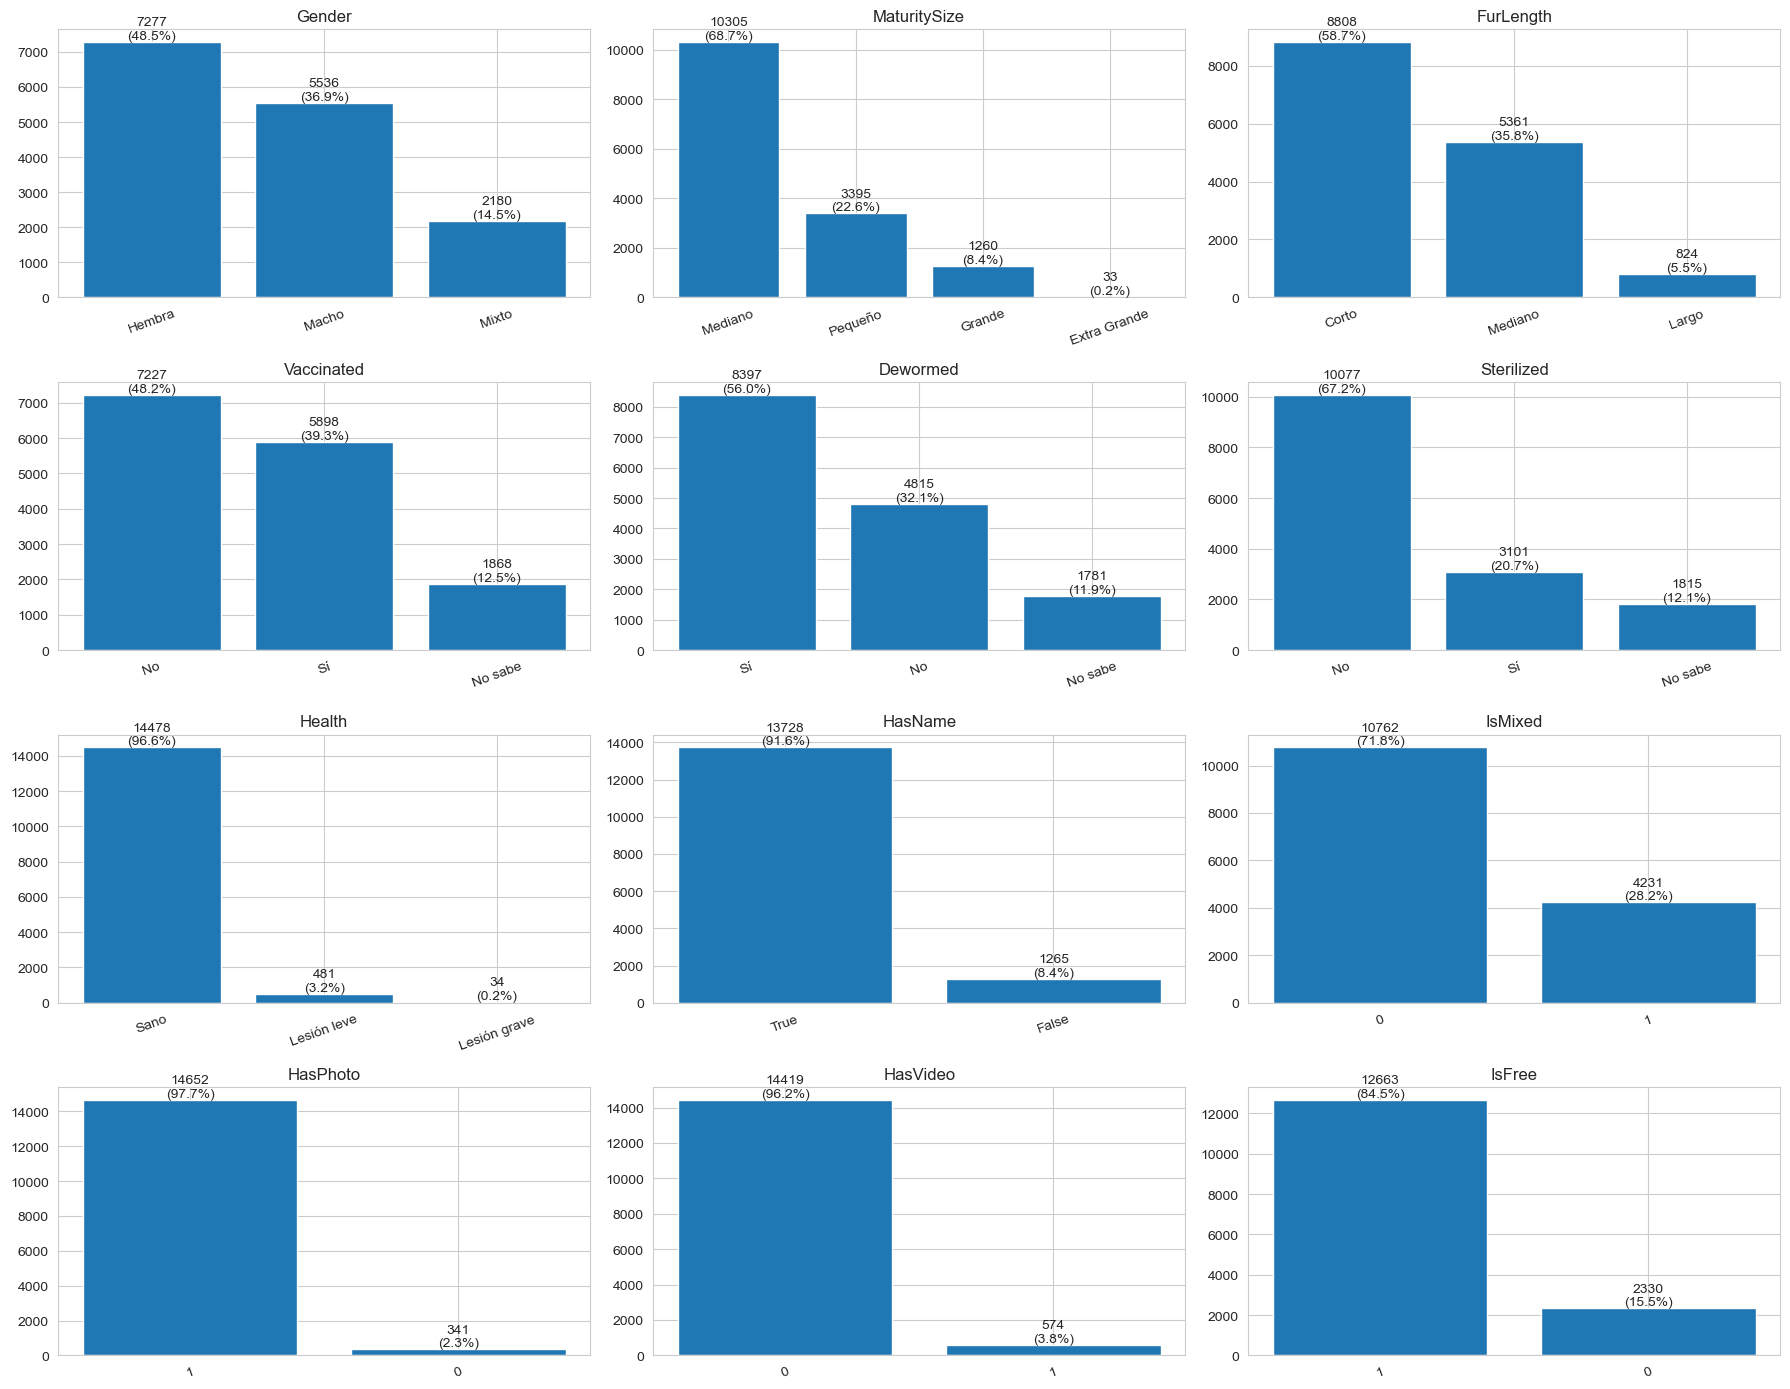

In [16]:
cat_cols = [
    'Gender', 'MaturitySize', 'FurLength',
    'Vaccinated', 'Dewormed', 'Sterilized', 'Health',
    'HasName', 'IsMixed', 'HasPhoto', 'HasVideo', 'IsFree'
]

fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    total = vc.sum()
    pct = vc / total * 100

    axes[i].bar(vc.index.astype(str), vc.values)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=20)

    for j, v in enumerate(vc.values):
        axes[i].text(
            j,
            v,
            f"{v}\n({pct.iloc[j]:.1f}%)",
            ha='center',
            va='bottom'
        )

# ocultar subplots vacíos
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- Predominan las hembras frente a machos y mixtos.
- La mayoría de los animales son de tamaño mediano y pelo corto, siendo minoría los de tamaño extremo y pelo largo.
- En cuanto al estado sanitario, la mayor parte de los animales están sanos, aunque muchos no están vacunados, desparasitados o esterilizados.
- Destaca que muchos animales no están esterilizados, lo que puede influir en su adopción.
- Entre las variables derivadas, la gran mayoría tiene nombre y publicaciones con fotos, lo cual podría favorecer la adopción. Sólo un breve porcentaje tiene videos.
- Predominan los animales no mestizos, aunque hay una proporción relevante de mestizos.
- Muchos animales son de adopción gratuita, lo que podría afectar la rapidez de adopción.

### 2.5 Distribución geográfica (Estado)

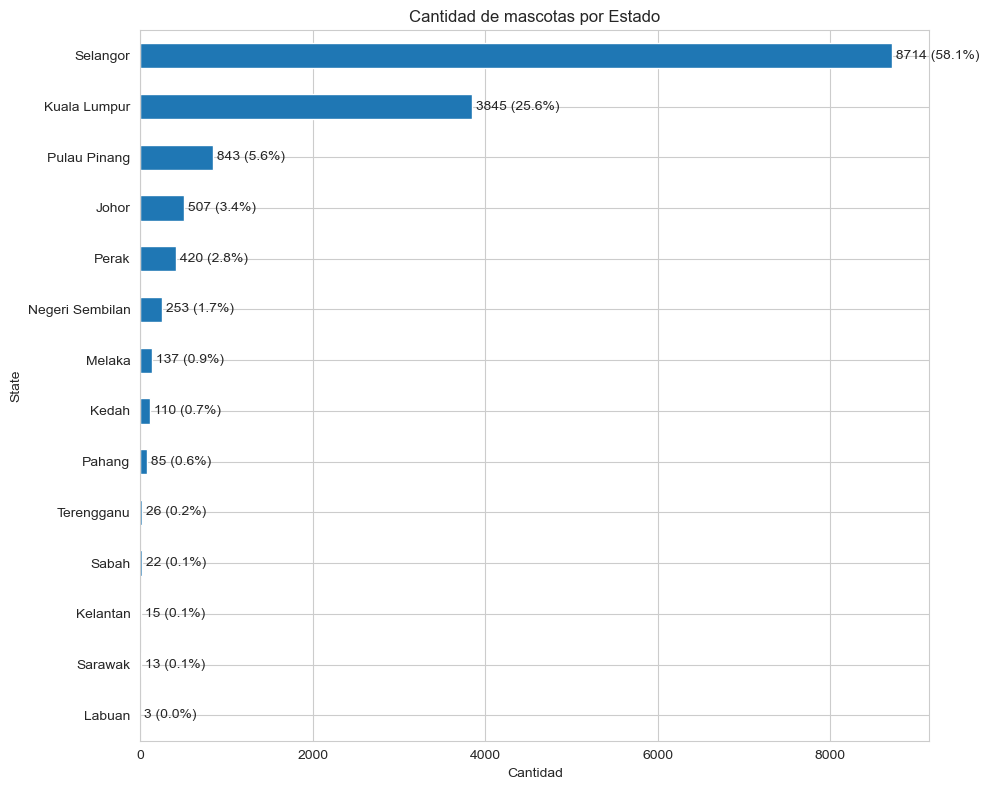

In [17]:
state_counts = df['State'].value_counts().sort_values(ascending=True)
state_pct = state_counts / state_counts.sum() * 100

plt.figure(figsize=(10, 8))
ax = state_counts.plot(kind='barh')

plt.title('Cantidad de mascotas por Estado')
plt.xlabel('Cantidad')

for i, v in enumerate(state_counts.values):
    ax.text(
        v,
        i,
        f' {v} ({state_pct.iloc[i]:.1f}%)',
        va='center'
    )

plt.tight_layout()
plt.show()

### 2.6 Nombres más frecuentes

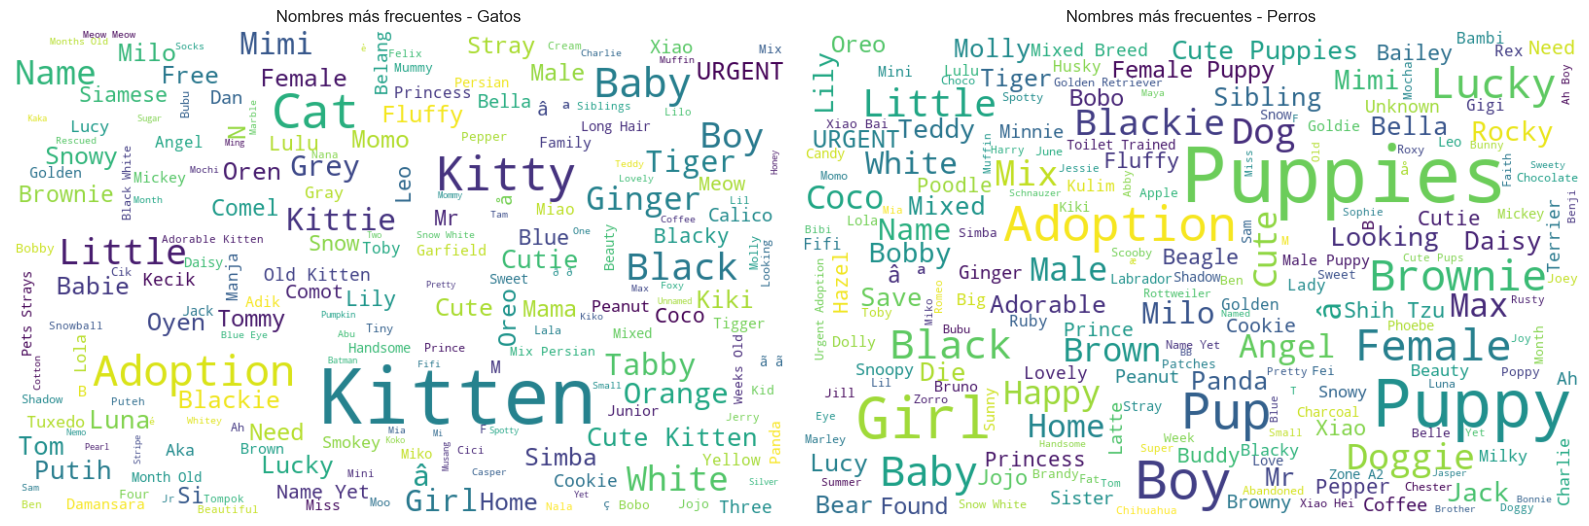

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, tipo in zip(axes, ['Gato', 'Perro']):
    text = ' '.join(df.loc[df['Type'] == tipo, 'Name'].dropna().values)
    if text.strip():
        wc = WordCloud(max_font_size=80, background_color='white',
                       width=800, height=500).generate(text)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'Nombres más frecuentes - {tipo}s')
        ax.axis('off')

plt.tight_layout()
plt.show()

---
## 3. Análisis Bivariado (relación con AdoptionSpeed)

In [19]:
# Función auxiliar: tasa de adopción rápida (clases 0+1) por categoría
def adoption_rate_by(col, df=df, fast_classes=(0, 1)):
    """Calcula % de adopción rápida por categoría."""
    result = df.groupby(col)['AdoptionSpeed'].apply(
        lambda x: (x.isin(fast_classes)).mean() * 100
    ).sort_values(ascending=False)
    return result

### 3.1 AdoptionSpeed según tipo de animal

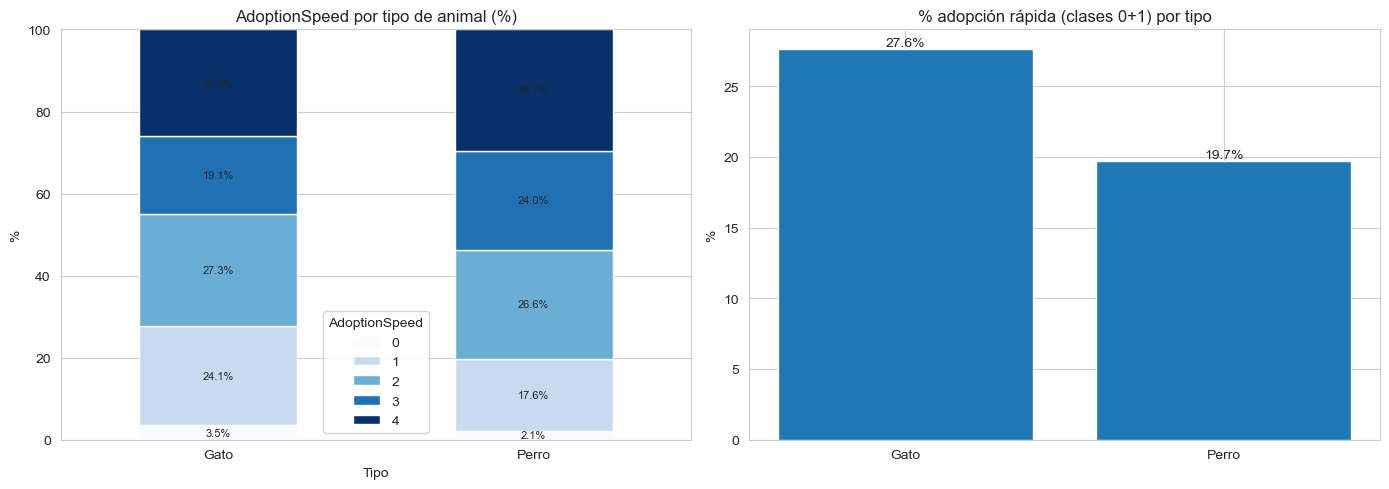

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# izquierda
cross = df.groupby(['Type', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

cross_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues', edgecolor='white')

axes[0].set_title('AdoptionSpeed por tipo de animal (%)')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('%')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)

for i, tipo in enumerate(cross_pct.index):
    cumulative = 0
    for speed in cross_pct.columns:
        pct = cross_pct.loc[tipo, speed]

        if pct > 0:
            axes[0].text(
                i,
                cumulative + pct / 2,
                f'{pct:.1f}%',
                ha='center',
                va='center',
                fontsize=8
            )
        cumulative += pct

# Derecha
rate = adoption_rate_by('Type')

bars = axes[1].bar(rate.index, rate.values)

axes[1].set_title('% adopción rápida (clases 0+1) por tipo')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)

# 👉 etiquetas (%)
for i, v in enumerate(rate.values):
    axes[1].text(
        i,
        v,
        f'{v:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

El tipo de animal parece influir en la velocidad de adopción. Los gatos tienden a adoptarse más rápido que los perros, mientras que los perros tienen mayor peso en clases más lentas (especialmente 3 y 4), lo que sugiere más dificultad para ser adoptados.

### 3.2 Edad y AdoptionSpeed

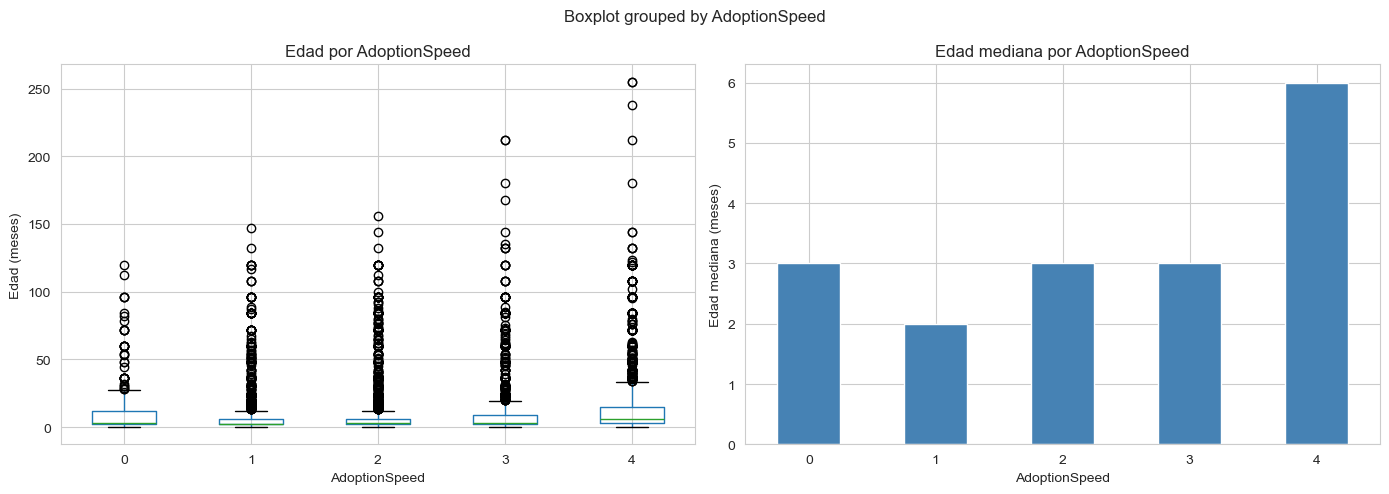

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de edad por clase de adopción
df.boxplot(column='Age', by='AdoptionSpeed', ax=axes[0])
axes[0].set_title('Edad por AdoptionSpeed')
axes[0].set_xlabel('AdoptionSpeed')
axes[0].set_ylabel('Edad (meses)')
plt.sca(axes[0])
plt.title('Edad por AdoptionSpeed')

# Edad promedio por clase
age_mean = df.groupby('AdoptionSpeed')['Age'].median()
age_mean.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Edad mediana por AdoptionSpeed')
axes[1].set_xlabel('AdoptionSpeed')
axes[1].set_ylabel('Edad mediana (meses)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Edad y velocidad de adopción tiene una relacion positiva: las mascotas más jóvenes tienden a adoptarse más rápido, mientras que a mayor edad aumenta la probabilidad de una adopción lenta. En las adopciones más lentas (especialmente clase 4), la edad mediana aumenta notablemente (≈6 meses), indicando mayor dificultad para adoptar animales más mayores.

### 3.3 Variables de salud y AdoptionSpeed

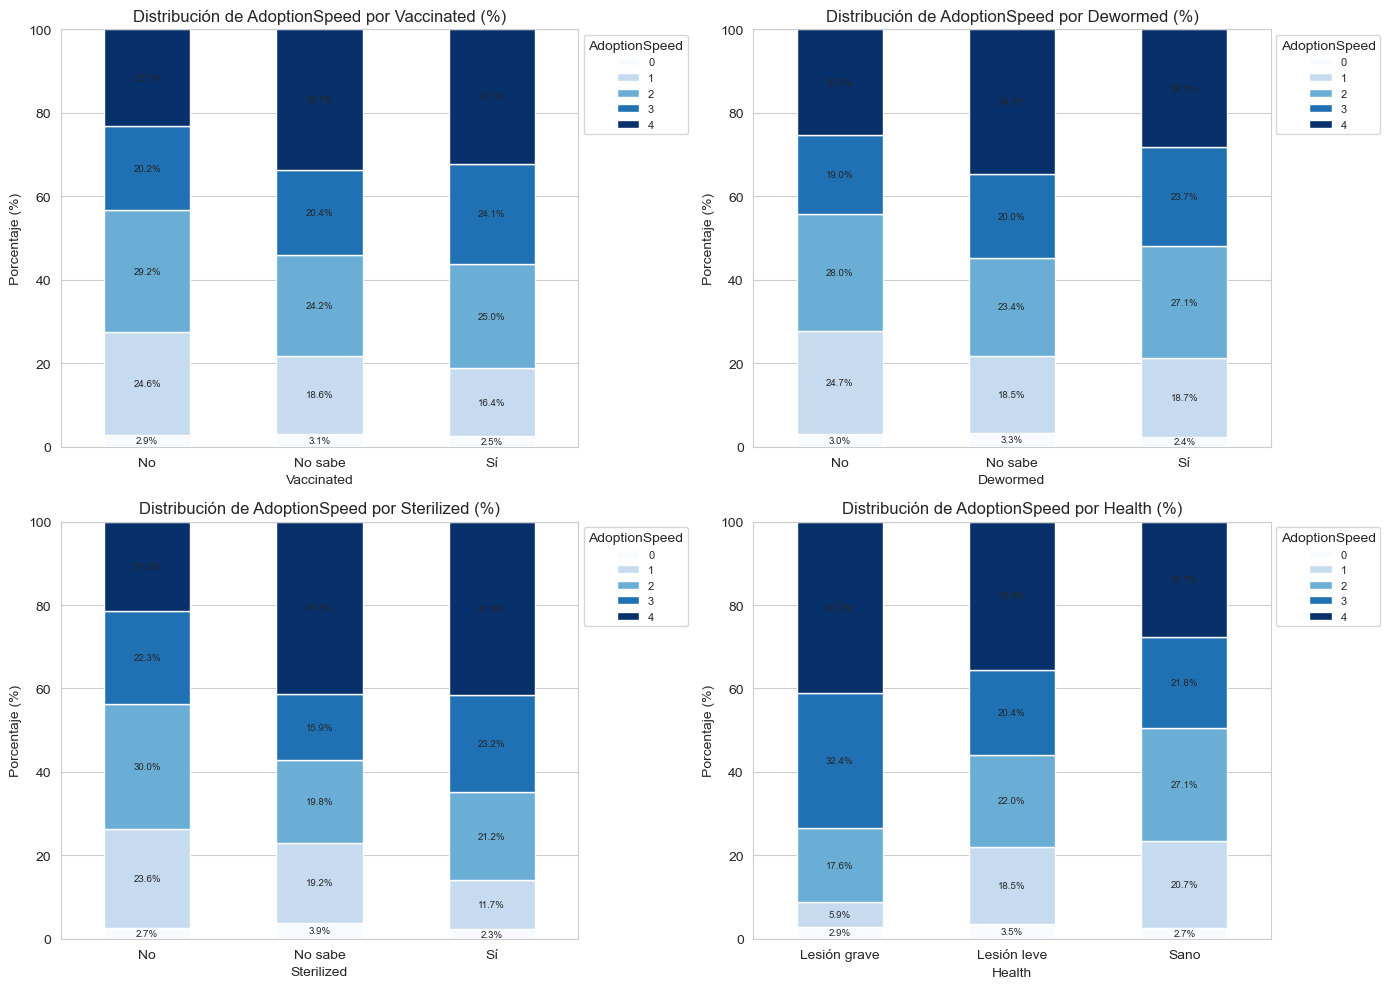

In [22]:
health_cols = ['Vaccinated', 'Dewormed', 'Sterilized', 'Health']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(health_cols):
    # Calcular proporciones
    cross = df.groupby([col, 'AdoptionSpeed']).size().unstack(fill_value=0)
    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

    cross_pct.plot(kind='bar', stacked=True, ax=axes[i], colormap='Blues', edgecolor='white')

    axes[i].set_title(f'Distribución de AdoptionSpeed por {col} (%)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Porcentaje (%)')
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=0)

    axes[i].legend(title='AdoptionSpeed', fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))

    for j, category in enumerate(cross_pct.index):
        cumulative = 0
        for speed in cross_pct.columns:
            pct = cross_pct.loc[category, speed]

            if pct > 0:
                axes[i].text(
                    j,
                    cumulative + pct / 2,
                    f'{pct:.1f}%',
                    ha='center',
                    va='center',
                    fontsize=7
                )
            cumulative += pct

plt.tight_layout()
plt.show()

El estado de salud parcece ser la variable más influyente: los animales sanos tienen mayor proporción de adopciones rápidas, y los que presentan lesiones (especialmente graves) se concentran en clases más altas.

El hecho de que las adopciones rápidas parecieran presentarse con más frecuencias en animales no vacunados, desparacitados o esterilizados puede puede estar mediado por otras características, como la edad.

### 3.4 Fee (tarifa) y AdoptionSpeed

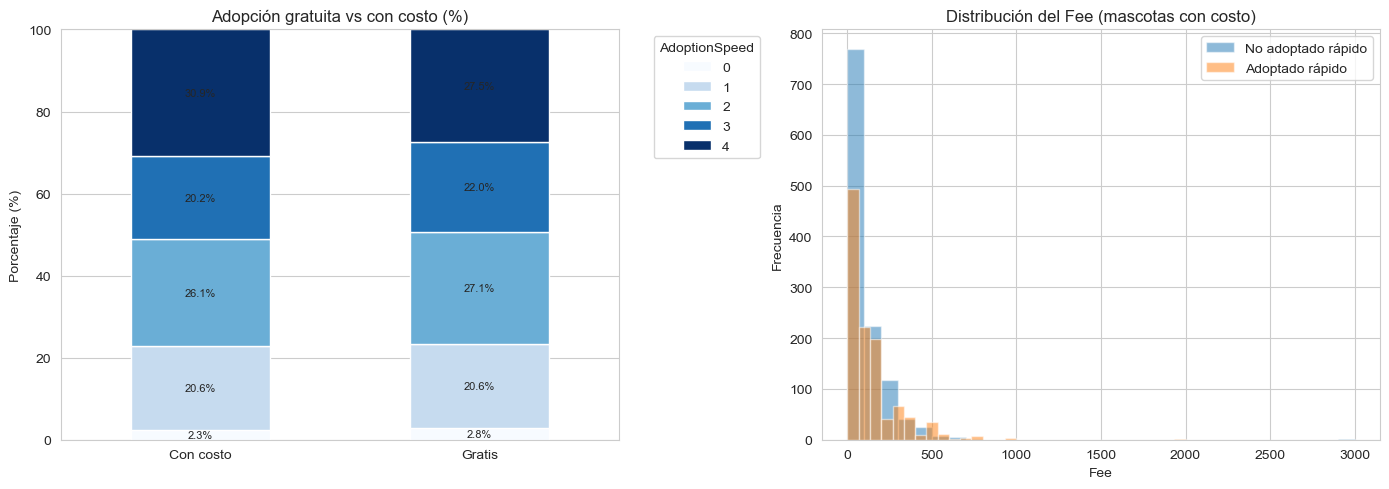

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gratis vs pago (izquierda)
cross = df.groupby(['IsFree', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
# Ajustamos los índices para que coincidan con la lógica de tu dataset
cross_pct.index = ['Con costo', 'Gratis']

cross_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues', edgecolor='white')

axes[0].set_title('Adopción gratuita vs con costo (%)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed', bbox_to_anchor=(1.05, 1), loc='upper left')

for i, category in enumerate(cross_pct.index):
    cumulative = 0
    for speed in cross_pct.columns:
        pct = cross_pct.loc[category, speed]

        if pct > 0:
            axes[0].text(
                i,
                cumulative + pct / 2,
                f'{pct:.1f}%',
                ha='center',
                va='center',
                fontsize=8
            )
        cumulative += pct

# 2. Distribución del fee para adoptados rápido vs lento (derecha)
df_fee = df[df['Fee'] > 0].copy()
# Definimos rápido como clases 0, 1 y 2
df_fee['Rapido'] = df_fee['AdoptionSpeed'].isin([0, 1, 2])

# Graficamos histogramas solapados
for status, group in df_fee.groupby('Rapido'):
    label = 'Adoptado rápido' if status else 'No adoptado rápido'
    axes[1].hist(group['Fee'], bins=30, alpha=0.5, label=label, edgecolor='white')

axes[1].set_title('Distribución del Fee (mascotas con costo)')
axes[1].set_xlabel('Fee')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

Las diferencias son pequeñas, pero las mascotas con costo concentran un poco más en adopciones lentas (especialmente clase 4). La distribución muestra que la mayoría de los precios están muy concentrados en valores bajos y que las mascotas adoptadas rápido tienden a tener fees más bajos.


### 3.5 Fotos, Videos y AdoptionSpeed

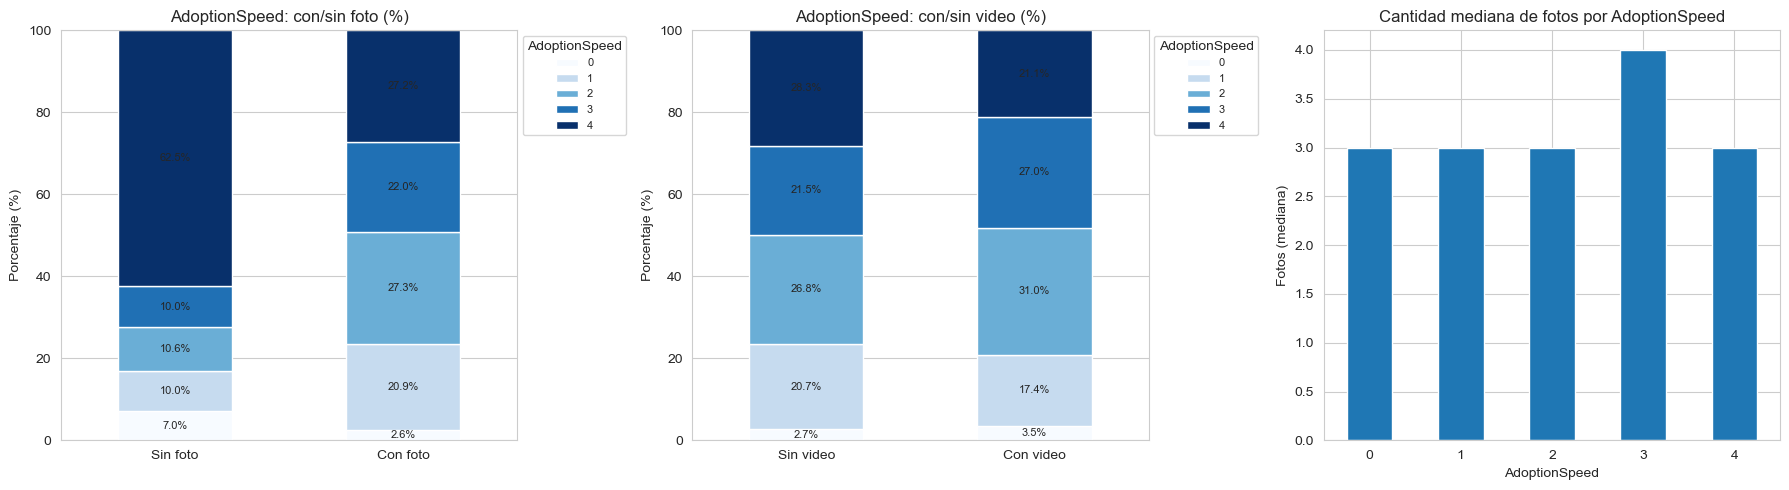

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Fotos (izquierda)
cross = df.groupby(['HasPhoto', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct.index = ['Sin foto', 'Con foto']

cross_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues', edgecolor='white')

axes[0].set_title('AdoptionSpeed: con/sin foto (%)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed', fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))

for i, category in enumerate(cross_pct.index):
    cumulative = 0
    for speed in cross_pct.columns:
        pct = cross_pct.loc[category, speed]
        if pct > 0:
            axes[0].text(i, cumulative + pct/2, f'{pct:.1f}%', ha='center', va='center', fontsize=8)
        cumulative += pct

# Video (centro)
cross2 = df.groupby(['HasVideo', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross2_pct = cross2.div(cross2.sum(axis=1), axis=0) * 100
cross2_pct.index = ['Sin video', 'Con video']

cross2_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Blues', edgecolor='white')

axes[1].set_title('AdoptionSpeed: con/sin video (%)')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='AdoptionSpeed', fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))

for i, category in enumerate(cross2_pct.index):
    cumulative = 0
    for speed in cross2_pct.columns:
        pct = cross2_pct.loc[category, speed]
        if pct > 0:
            axes[1].text(i, cumulative + pct/2, f'{pct:.1f}%', ha='center', va='center', fontsize=8)
        cumulative += pct

# Mediana fotos (derecha)
df.groupby('AdoptionSpeed')['PhotoAmt'].median().plot(
    kind='bar',
    ax=axes[2],
    edgecolor='white'
)

axes[2].set_title('Cantidad mediana de fotos por AdoptionSpeed')
axes[2].set_xlabel('AdoptionSpeed')
axes[2].set_ylabel('Fotos (mediana)')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

La ausencia de fotos se asocia fuertemente con una mayor proporción de no adopción. La presencia de video también se asocia con mejores resultados de adopción, pero número de casos es bajo.

### 3.6 Género y AdoptionSpeed

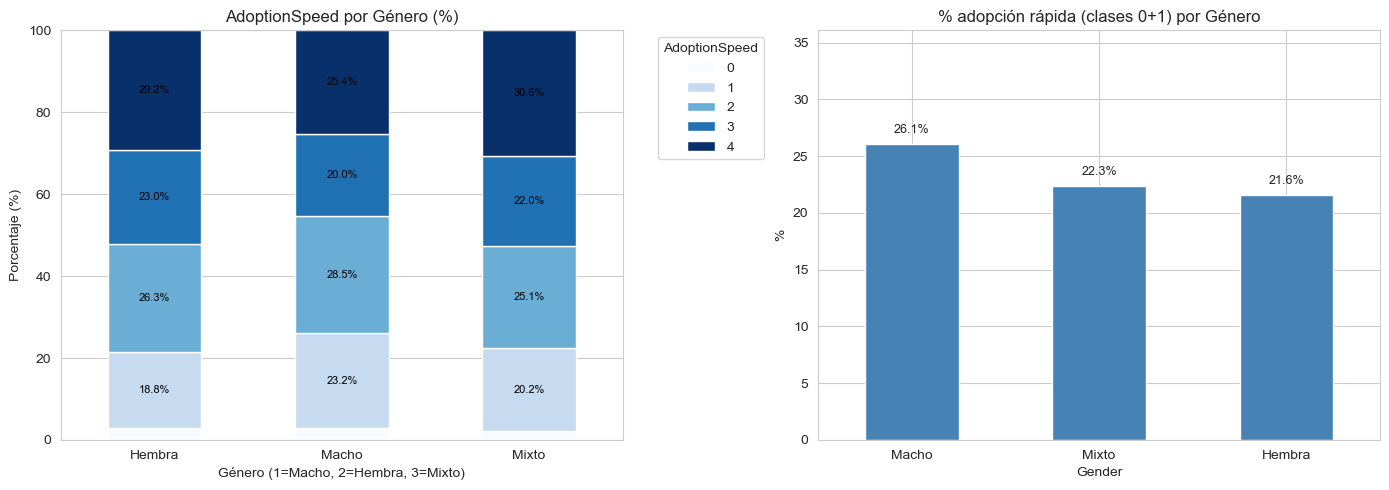

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. AdoptionSpeed por Género (izquierda)
cross = df.groupby(['Gender', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

ax0 = cross_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues', edgecolor='white')

for i, row in enumerate(cross_pct.values):
    acumulado = 0
    for j, val in enumerate(row):
        if val > 3:  # evitar etiquetas en segmentos muy chicos
            ax0.text(i, acumulado + val / 2, f'{val:.1f}%',
                     ha='center', va='center', fontsize=8, color='black')
        acumulado += val

axes[0].set_title('AdoptionSpeed por Género (%)')
axes[0].set_xlabel('Género (1=Macho, 2=Hembra, 3=Mixto)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed', bbox_to_anchor=(1.05, 1), loc='upper left')

# Tasa de adopción rápida por Género (derecha)
rate = adoption_rate_by('Gender')
ax1 = rate.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')

for i, val in enumerate(rate.values):
    ax1.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=9)

axes[1].set_title('% adopción rápida (clases 0+1) por Género')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, rate.max() + 10)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Los machos muestran una tendencia a adoptarse más rápido.

### 3.7 Nombre y AdoptionSpeed

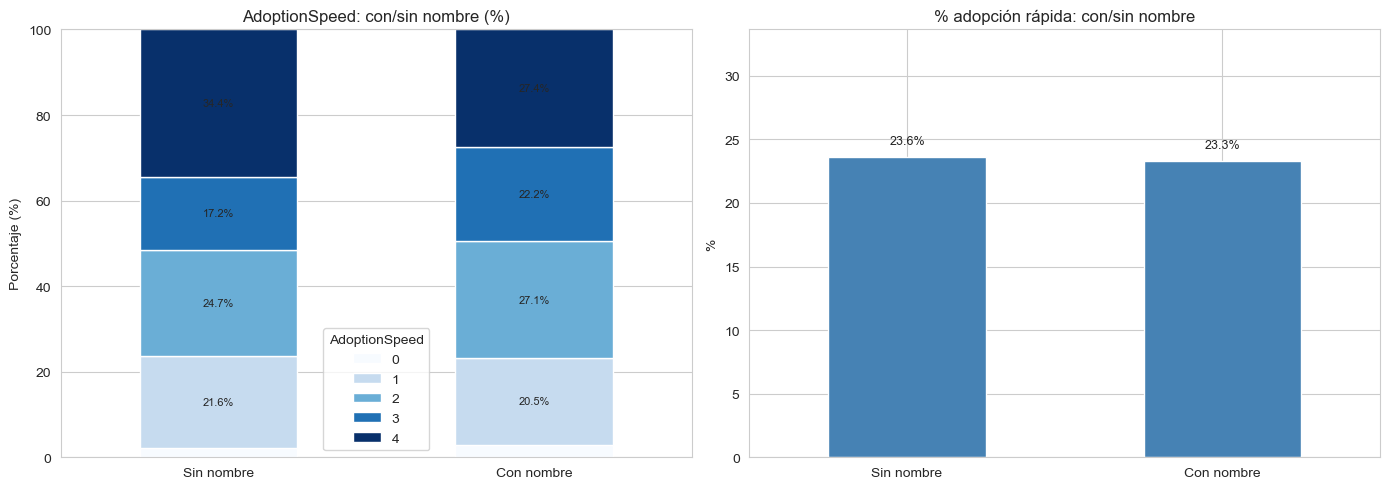

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cross = df.groupby(['HasName', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct.index = ['Sin nombre', 'Con nombre']

ax0 = cross_pct.plot(kind='bar', stacked=True, ax=axes[0],
                     colormap='Blues', edgecolor='white')

for i, row in enumerate(cross_pct.values):
    acumulado = 0
    for val in row:
        if val > 3:  # evita ruido visual
            ax0.text(i, acumulado + val/2, f'{val:.1f}%',
                     ha='center', va='center', fontsize=8)
        acumulado += val

axes[0].set_title('AdoptionSpeed: con/sin nombre (%)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed')

rate = df.groupby('HasName')['AdoptionSpeed'].apply(
    lambda x: (x.isin([0, 1])).mean() * 100
)
rate.index = ['Sin nombre', 'Con nombre']

ax1 = rate.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')

for i, val in enumerate(rate.values):
    ax1.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=9)

axes[1].set_title('% adopción rápida: con/sin nombre')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, rate.max() + 10)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

No se observan diferencias relevantes en la velocidad de adopción entre animales con y sin nombre.

### 3.8 Estado geográfico y AdoptionSpeed

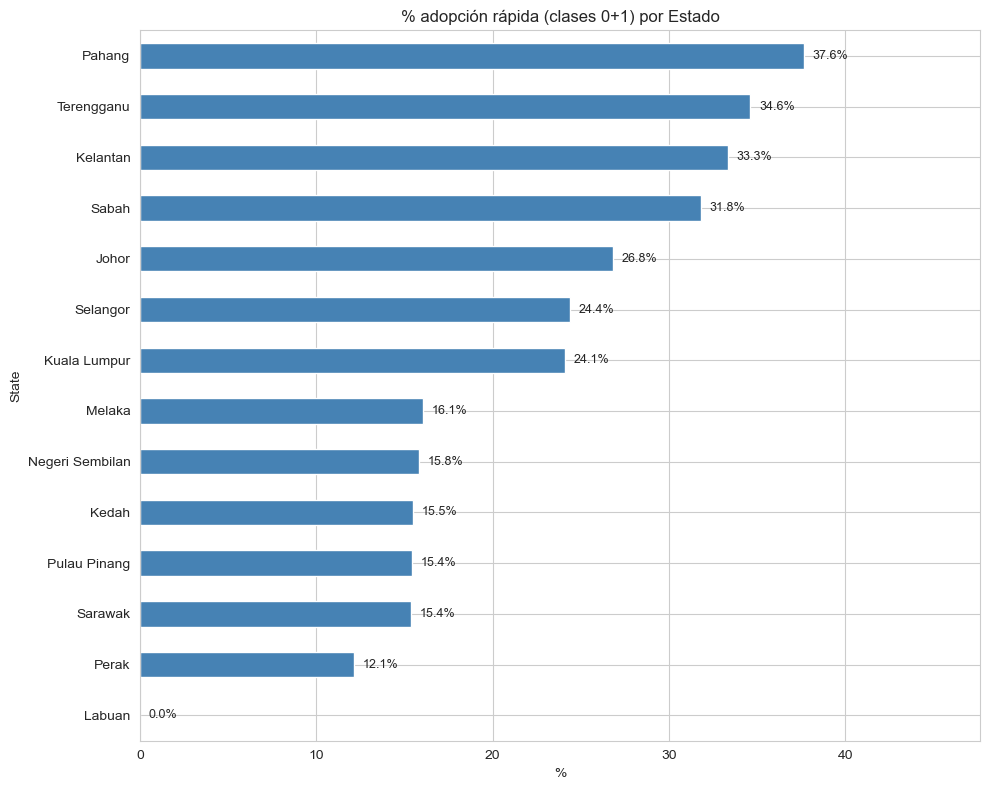

In [27]:
rate_state = adoption_rate_by('State').sort_values()

plt.figure(figsize=(10, 8))
ax = rate_state.plot(kind='barh', color='steelblue', edgecolor='white')

for i, val in enumerate(rate_state.values):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)

plt.title('% adopción rápida (clases 0+1) por Estado')
plt.xlabel('%')
plt.xlim(0, rate_state.max() + 10)  # margen para que entren los labels
plt.tight_layout()
plt.show()

### 3.9 Cantidad de mascotas (Quantity) y AdoptionSpeed

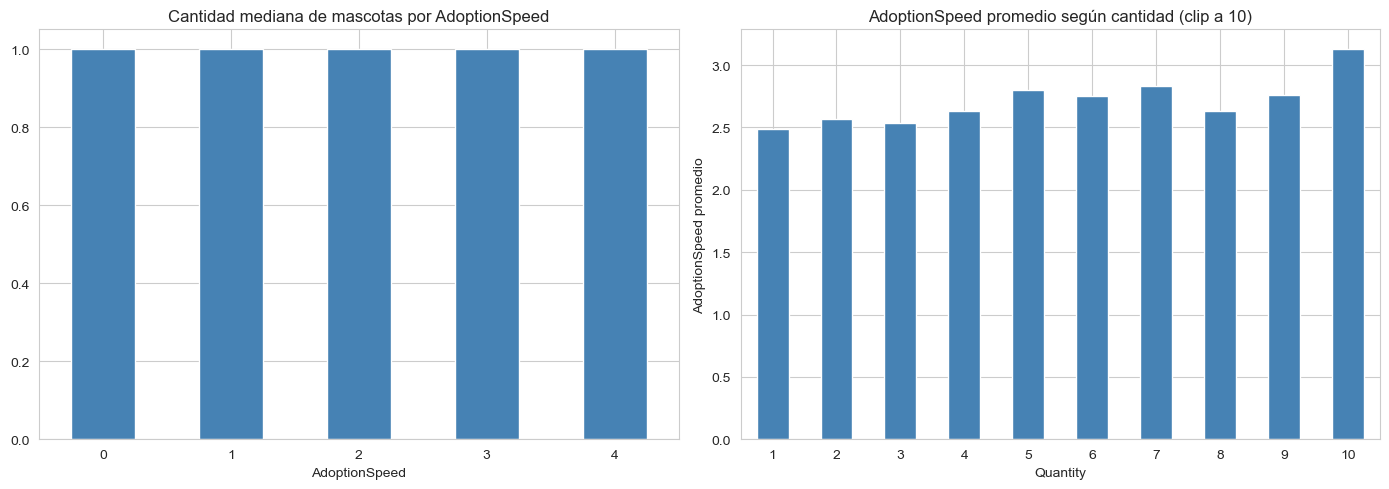

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('AdoptionSpeed')['Quantity'].median().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Cantidad mediana de mascotas por AdoptionSpeed')
axes[0].set_xlabel('AdoptionSpeed')
axes[0].tick_params(axis='x', rotation=0)

# Distribución de quantity
q_clip = df['Quantity'].clip(upper=10)
q_cross = df.groupby(q_clip)['AdoptionSpeed'].mean()
q_cross.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('AdoptionSpeed promedio según cantidad (clip a 10)')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('AdoptionSpeed promedio')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

La mayoría de las publicaciones son de una sola mascota, independientemente del resultado de adopción. Se observa que a medida que aumenta la cantidad, la velocidad de adopción promedio también aumenta, es decir, emperora. Publicaciones con más animales tienden a tardar más en lograr adopciones rápidas.

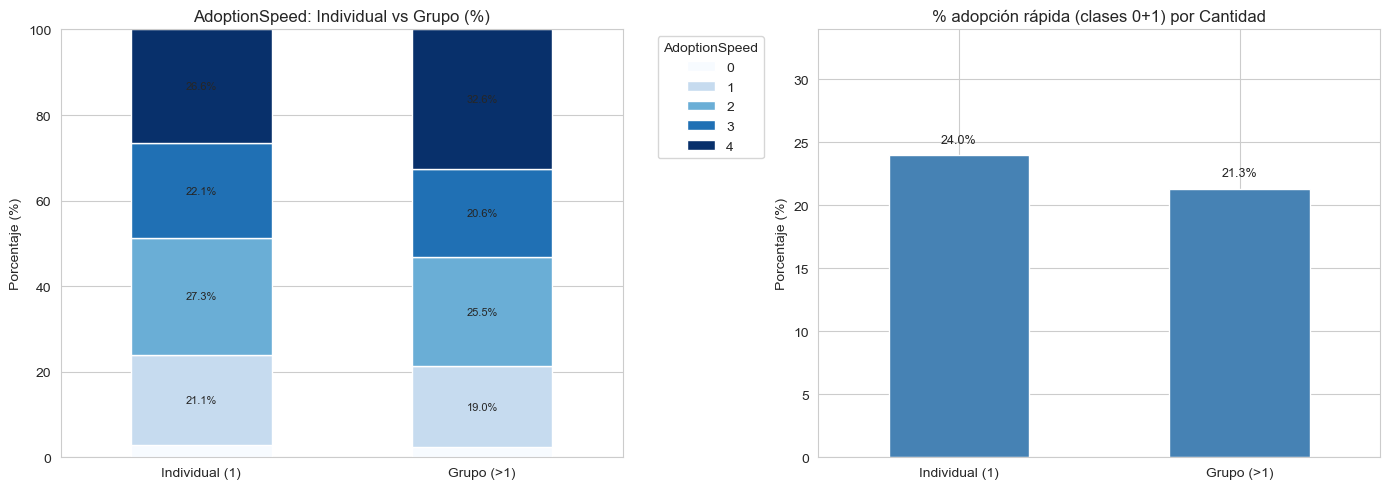

In [29]:
# 1. Crear variable dicotómica
df['IsGroup'] = (df['Quantity'] > 1).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cross = df.groupby(['IsGroup', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct.index = ['Individual (1)', 'Grupo (>1)']

ax0 = cross_pct.plot(kind='bar', stacked=True, ax=axes[0],
                     colormap='Blues', edgecolor='white')

for i, row in enumerate(cross_pct.values):
    acumulado = 0
    for val in row:
        if val > 3:
            ax0.text(i, acumulado + val/2, f'{val:.1f}%',
                     ha='center', va='center', fontsize=8)
        acumulado += val

axes[0].set_title('AdoptionSpeed: Individual vs Grupo (%)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed', bbox_to_anchor=(1.05, 1), loc='upper left')

rate = df.groupby('IsGroup')['AdoptionSpeed'].apply(
    lambda x: (x.isin([0, 1])).mean() * 100
)
rate.index = ['Individual (1)', 'Grupo (>1)']

ax1 = rate.plot(kind='bar', ax=axes[1],
                color='steelblue', edgecolor='white')

for i, val in enumerate(rate.values):
    ax1.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=9)

axes[1].set_title('% adopción rápida (clases 0+1) por Cantidad')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_ylim(0, rate.max() + 10)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Se observa una mayor proporción de adopción rápida en casos de un sólo animales, concentrándose más las adopciones lentas en las grupales.

---
## 4. Análisis Multivariado

### 4.1 Matriz de correlación (variables numéricas)

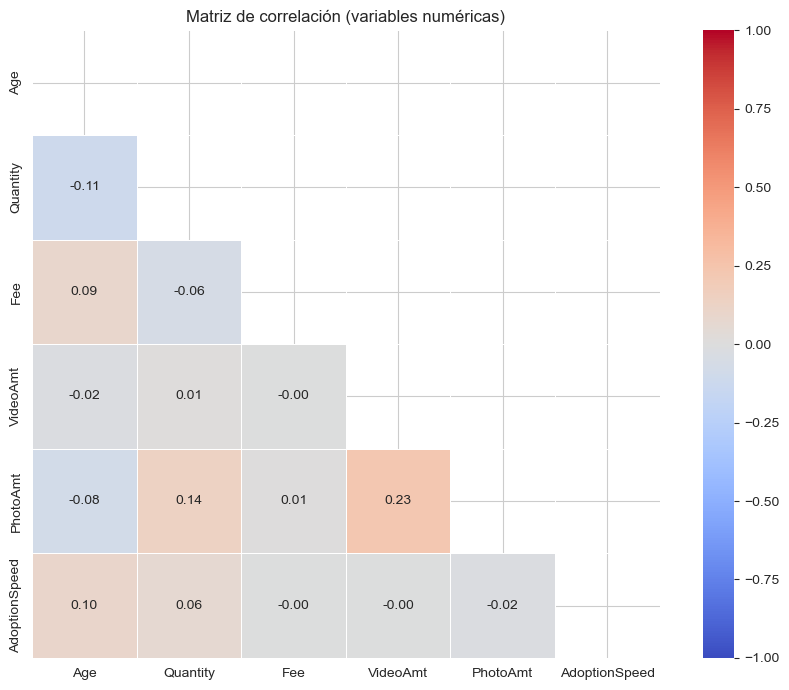

In [30]:
num_features = ['Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt', 'AdoptionSpeed']
corr = df[num_features].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Matriz de correlación (variables numéricas)')
plt.tight_layout()
plt.show()

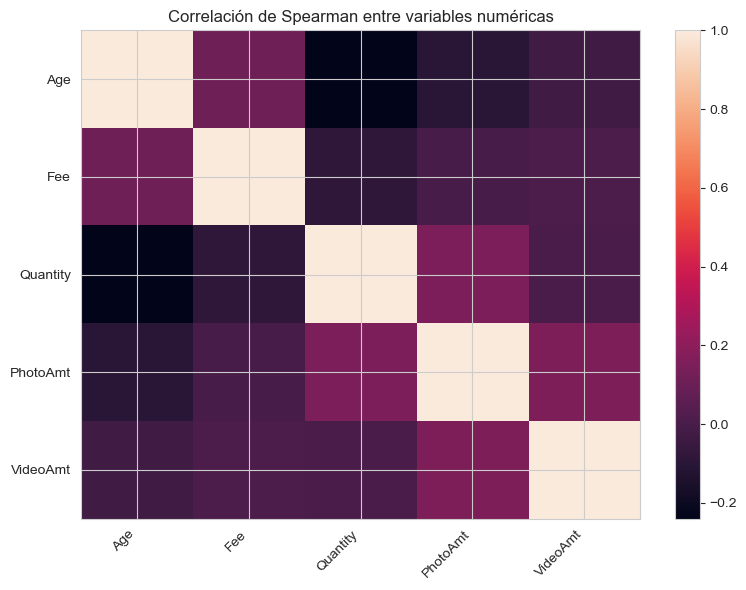

,Age,Fee,Quantity,PhotoAmt,VideoAmt
Age,1.000000,0.112785,-0.239861,-0.101358,-0.030555
Fee,0.112785,1.000000,-0.080122,-0.004158,0.008566
Quantity,-0.239861,-0.080122,1.000000,0.148199,-0.000007
PhotoAmt,-0.101358,-0.004158,0.148199,1.000000,0.153238
VideoAmt,-0.030555,0.008566,-0.000007,0.153238,1.000000


In [31]:
corr = df[num_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
ax.set_title("Correlación de Spearman entre variables numéricas")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

corr

Se observan correlaciones débiles entre las variables numéricas analizadas.
*  La relación más destacada se presenta entre la edad y la cantidad de animales por publicación, con una correlación negativa moderada, lo que sugiere que los animales más jóvenes suelen aparecer en publicaciones con mayor número de individuos.
*  Se observa una leve asociación positiva entre la cantidad de animales y el número de fotografías.

### 4.2 Tipo de animal × Edad × AdoptionSpeed

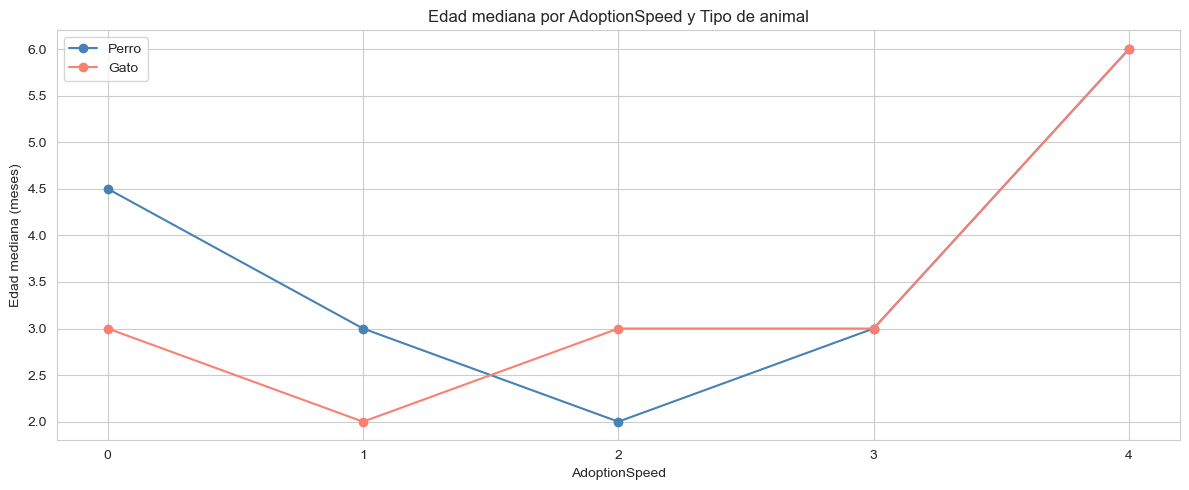

In [32]:
plt.figure(figsize=(12, 5))
for tipo, color in [('Perro', 'steelblue'), ('Gato', 'salmon')]:
    subset = df[df['Type'] == tipo]
    mean_age = subset.groupby('AdoptionSpeed')['Age'].median()
    plt.plot(mean_age.index, mean_age.values, marker='o', label=tipo, color=color)

plt.title('Edad mediana por AdoptionSpeed y Tipo de animal')
plt.xlabel('AdoptionSpeed')
plt.ylabel('Edad mediana (meses)')
plt.xticks([0, 1, 2, 3, 4])
plt.legend()
plt.tight_layout()
plt.show()

### 4.3 Tipo × Variables de salud × AdoptionSpeed

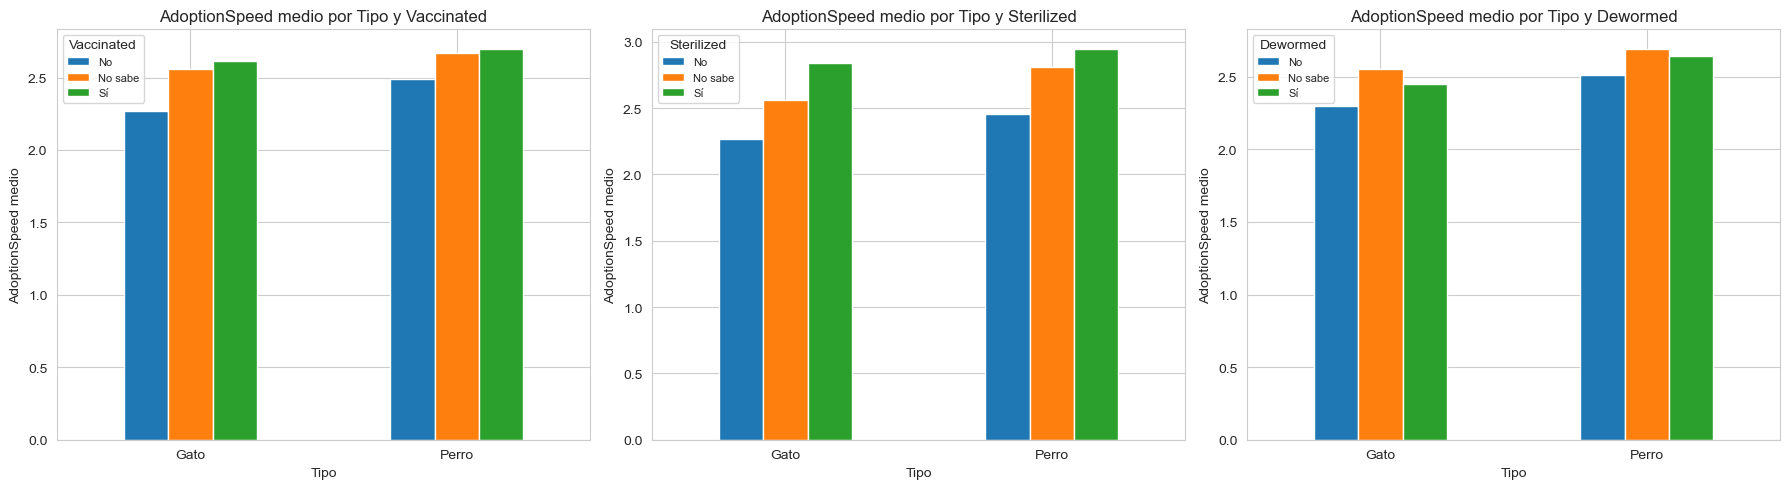

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['Vaccinated', 'Sterilized', 'Dewormed']):
    pivot = df.groupby(['Type', col])['AdoptionSpeed'].mean().unstack()
    pivot.plot(kind='bar', ax=ax, edgecolor='white')
    ax.set_title(f'AdoptionSpeed medio por Tipo y {col}')
    ax.set_xlabel('Tipo')
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylabel('AdoptionSpeed medio')
    ax.legend(title=col, fontsize=8)

plt.tight_layout()
plt.show()

### 4.4 Tipo × Fee × AdoptionSpeed

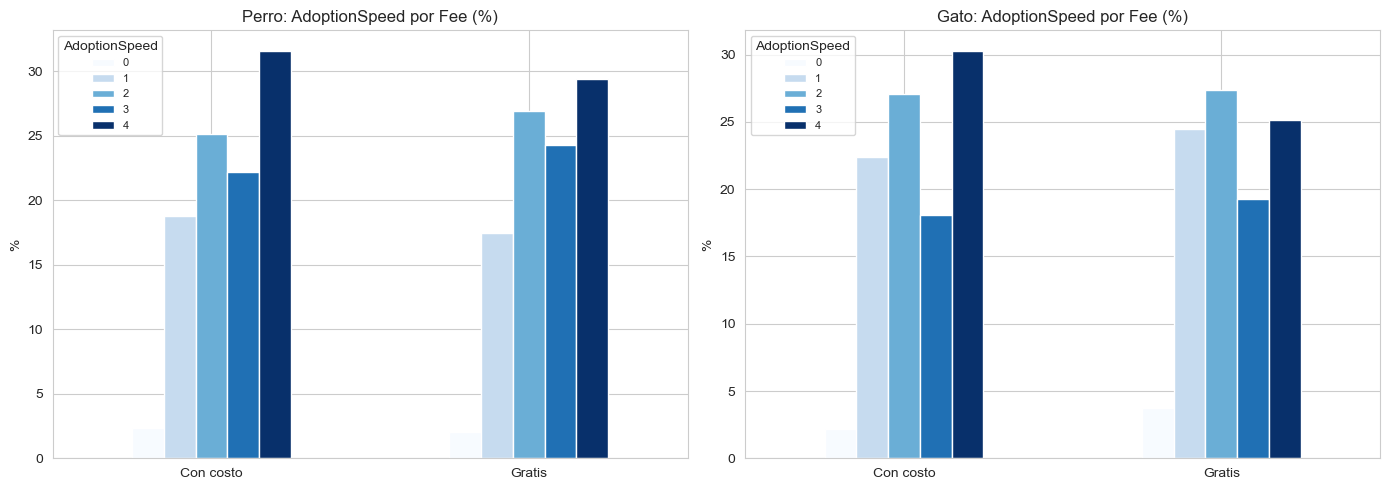

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tipo in zip(axes, ['Perro', 'Gato']):
    subset = df[df['Type'] == tipo]
    cross = subset.groupby(['IsFree', 'AdoptionSpeed']).size().unstack(fill_value=0)
    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
    cross_pct.index = ['Con costo', 'Gratis']
    cross_pct.plot(kind='bar', ax=ax, colormap='Blues', edgecolor='white')
    ax.set_title(f'{tipo}: AdoptionSpeed por Fee (%)')
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylabel('%')
    ax.legend(title='AdoptionSpeed', fontsize=8)

plt.tight_layout()
plt.show()

### 4.5 Fotos × Tipo × AdoptionSpeed

C:\Users\Patricia\AppData\Local\Temp\ipykernel_8772\905222417.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = subset.groupby('PhotoGroup')['AdoptionSpeed'].mean().reset_index()
C:\Users\Patricia\AppData\Local\Temp\ipykernel_8772\905222417.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = subset.groupby('PhotoGroup')['AdoptionSpeed'].mean().reset_index()


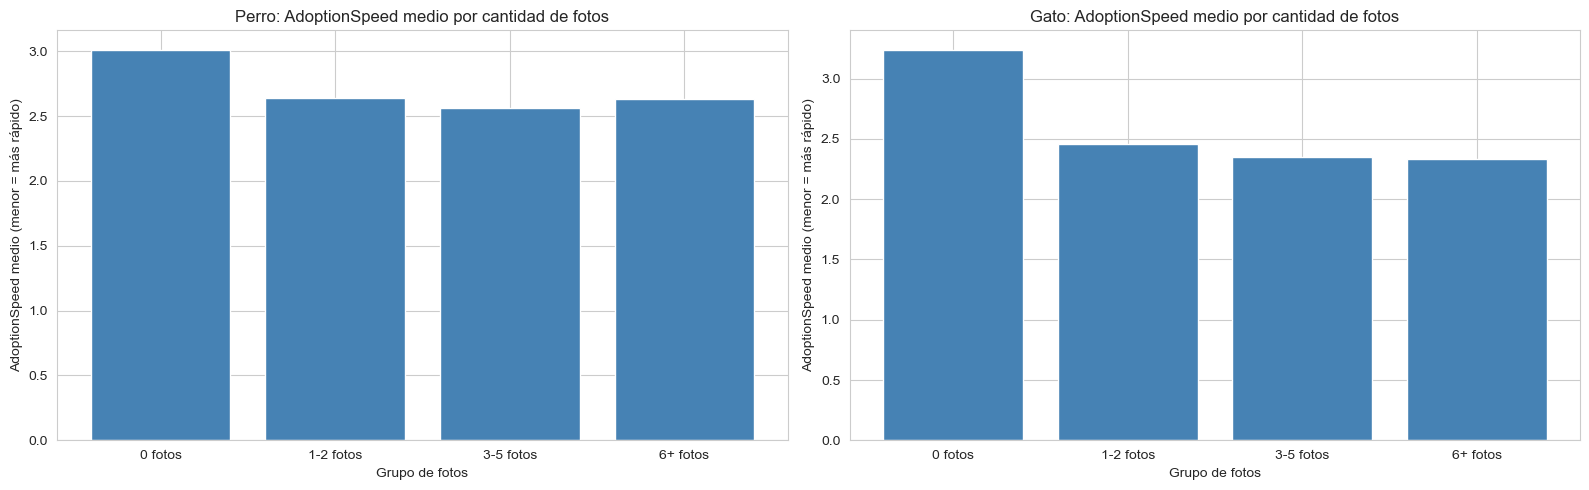

In [35]:
# Categorizar cantidad de fotos
df['PhotoGroup'] = pd.cut(df['PhotoAmt'].fillna(0),
                           bins=[-1, 0, 2, 5, 100],
                           labels=['0 fotos', '1-2 fotos', '3-5 fotos', '6+ fotos'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, tipo in zip(axes, ['Perro', 'Gato']):
    subset = df[df['Type'] == tipo]
    pivot = subset.groupby('PhotoGroup')['AdoptionSpeed'].mean().reset_index()
    ax.bar(pivot['PhotoGroup'].astype(str), pivot['AdoptionSpeed'], color='steelblue')
    ax.set_title(f'{tipo}: AdoptionSpeed medio por cantidad de fotos')
    ax.set_xlabel('Grupo de fotos')
    ax.set_ylabel('AdoptionSpeed medio (menor = más rápido)')

plt.tight_layout()
plt.show()

### 4.6 Pairplot: variables numéricas clave coloreadas por AdoptionSpeed

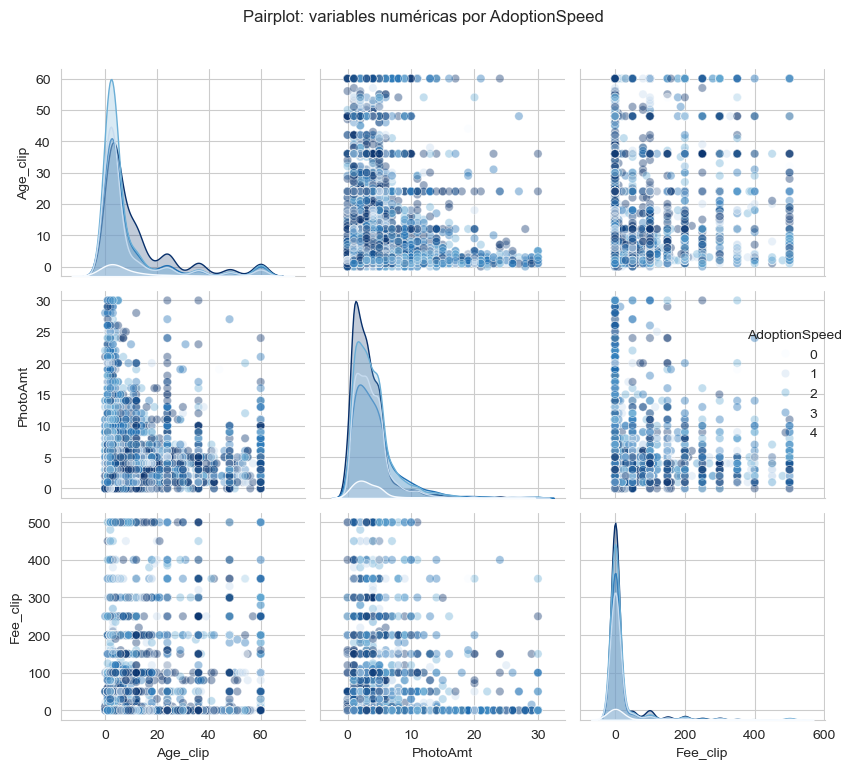

In [36]:
pair_cols = ['Age', 'PhotoAmt', 'Fee', 'AdoptionSpeed']
pair_df = df[pair_cols].copy()
pair_df['PhotoAmt'] = pair_df['PhotoAmt'].fillna(0)
pair_df['Fee_clip'] = pair_df['Fee'].clip(upper=500)
pair_df['Age_clip'] = pair_df['Age'].clip(upper=60)

g = sns.pairplot(pair_df[['Age_clip', 'PhotoAmt', 'Fee_clip', 'AdoptionSpeed']],
                 hue='AdoptionSpeed', palette='Blues', plot_kws={'alpha': 0.4},
                 diag_kind='kde')
g.fig.suptitle('Pairplot: variables numéricas por AdoptionSpeed', y=1.02)
plt.tight_layout()
plt.show()

### 4.7 Heatmap: tasa de adopción rápida por Estado y Tipo

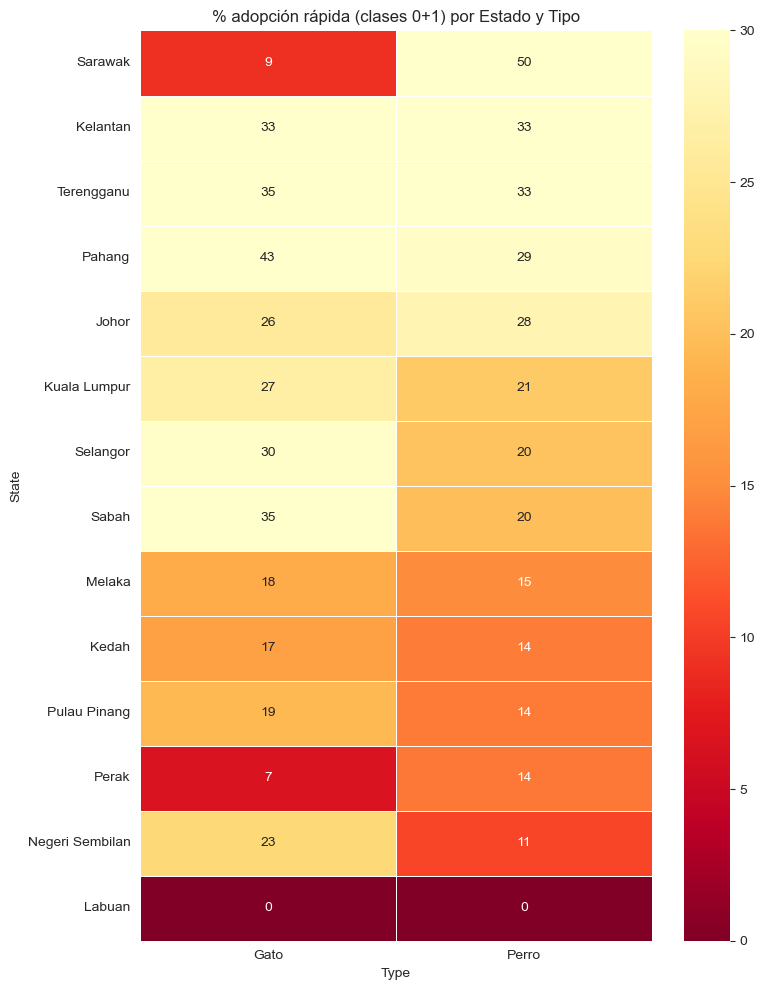

In [37]:
pivot_state = df.groupby(['State', 'Type'])['AdoptionSpeed'].apply(
    lambda x: (x.isin([0, 1])).mean() * 100
).unstack()

plt.figure(figsize=(8, 10))
sns.heatmap(pivot_state.sort_values('Perro', ascending=False),
            annot=True, fmt='.0f', cmap='YlOrRd_r',
            linewidths=0.5, vmin=0, vmax=30)
plt.title('% adopción rápida (clases 0+1) por Estado y Tipo')
plt.tight_layout()
plt.show()

---
## 5. Resumen y conclusiones preliminares

### Hallazgos principales

**Sobre el target:**
- Las clases 2 y 3 (adopción en 1er mes o en 2do-3er mes) son las más frecuentes. La distribución no es uniforme.
- Solo una pequeña proporción se adopta el mismo día (clase 0).

**Variables más relevantes para el modelo:**
- **Tipo**: Los gatos tienden a tener velocidades de adopción distintas a los perros; conviene modelar con esta variable.
- **Edad**: Las mascotas más jóvenes se adoptan más rápido. Variable continua con sesgo hacia valores bajos.
- **Fotos**: Tener fotos (y más fotos) se asocia con adopciones más rápidas.
- **Fee**: Las mascotas gratuitas tienden a adoptarse de forma diferente a las que tienen costo.
- **Vacunación / Esterilización / Desparasitación**: Las mascotas con estado conocido (Sí/No) se adoptan más rápido que las de estado "No sabe".
- **Nombre**: Tener nombre muestra una leve diferencia en velocidad de adopción.
- **Estado geográfico**: Hay variación regional importante.

**Consideraciones para el modelado:**
- `PhotoAmt` tiene valores nulos — imputar con 0.
- Variables categóricas ordinales (`Vaccinated`, `Sterilized`, etc.) necesitan encoding cuidadoso.
- `Age` y `Fee` tienen distribuciones con cola larga — considerar transformaciones o clipping.
- `RescuerID` tiene alta cardinalidad — requiere encoding especial (target encoding o embeddings).
- `Description` es texto libre — puede ser fuente de señal adicional mediante NLP.
- Las imágenes disponibles (`PhotoAmt > 0`) pueden aportar señal visual.
- Crear variable tipo idioma de la descripción - Ver sentiment - Normalizar todo al inglés

## Feature Engineering

In [38]:
# 1. Binning de Edad (Age está en meses)
def bin_age(age):
    if age <= 6:
        return 'Puppy/Kitten'
    elif age <= 24:
        return 'Young'
    elif age <= 84:
        return 'Adult'
    else:
        return 'Senior'

df['AgeGroup'] = df['Age'].apply(bin_age)

# 2. Flags Booleanos adicionales
# IsFree ya está en tu notebook: (df['Fee'] == 0).astype(int)

# IsPureBreed: No tiene raza secundaria y la primaria no es "Mixed Breed"
df['IsPureBreed'] = ((train['Breed2'] == 0) & (df['Breed1'] != 'Mixed Breed')).astype(int)

# HasDescription: Verifica si existe texto en la descripción
df['HasDescription'] = df['Description'].notna().astype(int)

# 3. Características de Texto: Longitud de la descripción (conteo de palabras)
df['DescriptionWordCount'] = df['Description'].fillna('').apply(lambda x: len(x.split()))

# 4. Agregaciones por Rescatista: Cantidad de mascotas publicadas por el mismo ID
df['RescuerPetCount'] = df.groupby('RescuerID')['PetID'].transform('count')

# 5. Interacción entre Foto y Video
df['HasBothPhotoVideo'] = ((df['HasPhoto'] == 1) & (df['HasVideo'] == 1)).astype(int)

# Visualizar los nuevos atributos
print(df[['Age', 'AgeGroup', 'IsPureBreed', 'DescriptionWordCount', 'RescuerPetCount']].head())

   Age      AgeGroup  IsPureBreed  DescriptionWordCount  RescuerPetCount
0    3  Puppy/Kitten            1                    69                8
1    1  Puppy/Kitten            1                    23                1
2    1  Puppy/Kitten            0                    69              459
3    4  Puppy/Kitten            0                    25               50
4    1  Puppy/Kitten            0                    81              134


In [39]:
df.columns

Index(['Type', 'Name', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2',
       'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed',
       'Sterilized', 'Health', 'Quantity', 'Fee', 'State', 'RescuerID',
       'VideoAmt', 'Description', 'PetID', 'PhotoAmt', 'AdoptionSpeed',
       'HasName', 'IsMixed', 'HasPhoto', 'HasVideo', 'IsFree', 'IsGroup',
       'PhotoGroup', 'AgeGroup', 'IsPureBreed', 'HasDescription',
       'DescriptionWordCount', 'RescuerPetCount', 'HasBothPhotoVideo'],
      dtype='object')

In [40]:
df.head(5)

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,...,PhotoAmt,AdoptionSpeed,HasName,IsMixed,HasPhoto,HasVideo,IsFree,IsGroup,PhotoGroup,AgeGroup,IsPureBreed,HasDescription,DescriptionWordCount,RescuerPetCount,HasBothPhotoVideo
0,Gato,Nibble,3,Tabby,NaN,Macho,Black,White,NaN,Pequeño,Corto,No,No,No,Sano,...,1.0,2,True,0,1,0,0,0,1-2 fotos,Puppy/Kitten,1,1,69,8,0
1,Gato,No Name Yet,1,Domestic Medium Hair,NaN,Macho,Black,Brown,NaN,Mediano,Mediano,No sabe,No sabe,No sabe,Sano,...,2.0,0,True,0,1,0,1,0,1-2 fotos,Puppy/Kitten,1,1,23,1,0
2,Perro,Brisco,1,Mixed Breed,NaN,Macho,Brown,White,NaN,Mediano,Mediano,Sí,Sí,No,Sano,...,7.0,3,True,0,1,0,1,0,6+ fotos,Puppy/Kitten,0,1,69,459,0
3,Perro,Miko,4,Mixed Breed,NaN,Hembra,Black,Brown,NaN,Mediano,Corto,Sí,Sí,No,Sano,...,8.0,2,True,0,1,0,0,0,6+ fotos,Puppy/Kitten,0,1,25,50,0
4,Perro,Hunter,1,Mixed Breed,NaN,Macho,Black,NaN,NaN,Mediano,Corto,No,No,No,Sano,...,3.0,2,True,0,1,0,1,0,3-5 fotos,Puppy/Kitten,0,1,81,134,0


### Modelo de prueba RF

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import cohen_kappa_score, classification_report
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

df_rf = df.copy()

In [42]:
# 1. Seleccionar automáticamente columnas numéricas (enteros y decimales)
num_features = df_rf.select_dtypes(include=[np.number]).columns.tolist()

# 2. Seleccionar automáticamente columnas categóricas (texto o categorías)
cat_features = df_rf.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas detectadas:", num_features)
print("Categóricas detectadas:", cat_features)

Numéricas detectadas: ['Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt', 'AdoptionSpeed', 'IsMixed', 'HasPhoto', 'HasVideo', 'IsFree', 'IsGroup', 'IsPureBreed', 'HasDescription', 'DescriptionWordCount', 'RescuerPetCount', 'HasBothPhotoVideo']
Categóricas detectadas: ['Type', 'Name', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State', 'RescuerID', 'Description', 'PetID', 'HasName', 'PhotoGroup', 'AgeGroup']


In [67]:
# 1. Definir lo que NO queremos en el modelo
columnas_target = ['AdoptionSpeed', 'AdoptFast']
columnas_texto_id = ['Name', 'Description', 'RescuerID', 'PetID']
columnas_redundantes = ['TypeLabel', 'VaccinatedLabel', 'DewormedLabel', 'SterilizedLabel', 'HealthLabel', 'FeeGroup', 'PhotoGroup']

eliminar = columnas_target + columnas_texto_id + columnas_redundantes

# 2. Filtrar las listas detectadas automáticamente
num_features_limpias = [col for col in num_features if col not in eliminar]
cat_features_limpias = [col for col in cat_features if col not in eliminar]

print("Numéricas listas para el modelo:", num_features_limpias)
print("\nCategóricas listas para el modelo:", cat_features_limpias)

# 3. Ahora sí, armas tu X y tu y
X = df_rf[num_features_limpias + cat_features_limpias]
y = df_rf['AdoptionSpeed'] # Target

Numéricas listas para el modelo: ['Age', 'Fee', 'VideoAmt', 'PhotoAmt', 'DescriptionWordCount', 'RescuerPetCount', 'Quantity']

Categóricas listas para el modelo: ['Type', 'Breed1', 'Gender', 'Color1', 'MaturitySize', 'FurLength', 'Vaccinated', 'Sterilized', 'Health', 'AgeGroup']


In [68]:
X.head()

,Age,Fee,VideoAmt,PhotoAmt,DescriptionWordCount,RescuerPetCount,Quantity,Type,Breed1,Gender,Color1,MaturitySize,FurLength,Vaccinated,Sterilized,Health,AgeGroup
0,3,100,0,1.0,69,8,1,Gato,Tabby,Macho,Black,Pequeño,Corto,No,No,Sano,Puppy/Kitten
1,1,0,0,2.0,23,1,1,Gato,Domestic Medium Hair,Macho,Black,Mediano,Mediano,No sabe,No sabe,Sano,Puppy/Kitten
2,1,0,0,7.0,69,459,1,Perro,Mixed Breed,Macho,Brown,Mediano,Mediano,Sí,No,Sano,Puppy/Kitten
3,4,150,0,8.0,25,50,1,Perro,Mixed Breed,Hembra,Black,Mediano,Corto,Sí,No,Sano,Puppy/Kitten
4,1,0,0,3.0,81,134,1,Perro,Mixed Breed,Macho,Black,Mediano,Corto,No,No,Sano,Puppy/Kitten


In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder


preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features_limpias), # Las numéricas pasan tal cual
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_features_limpias)
    ])

# Unir preprocesamiento y modelo
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1))
])

# 6. Split de datos
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 7. Entrenamiento
print("\nEntrenando el modelo Random Forest con Pipeline...")
rf_pipeline.fit(X_train, y_train)




Entrenando el modelo Random Forest con Pipeline...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [45]:
# 1. Configurar el preprocesador para que devuelva un DataFrame de Pandas
preprocessor.set_output(transform="pandas")

# 2. Entrenar todo el pipeline (si no lo habías hecho ya)
rf_pipeline.fit(X_train, y_train)

# 3. Extraer solo el preprocesador ya entrenado desde el pipeline
fitted_preprocessor = rf_pipeline.named_steps['preprocessor']

# 4. Transformar X_train usando ese preprocesador
X_train_transformed_df = fitted_preprocessor.transform(X_train)

# 5. Ver una muestra aleatoria de 5 filas
muestra = X_train_transformed_df.sample(5)
display(muestra)

,num__Age,num__Quantity,num__Fee,num__VideoAmt,num__PhotoAmt,num__IsMixed,num__HasPhoto,num__HasVideo,num__IsFree,num__IsGroup,num__IsPureBreed,num__HasDescription,num__DescriptionWordCount,num__RescuerPetCount,num__HasBothPhotoVideo,...,cat__Breed1,cat__Breed2,cat__Gender,cat__Color1,cat__Color2,cat__Color3,cat__MaturitySize,cat__FurLength,cat__Vaccinated,cat__Dewormed,cat__Sterilized,cat__Health,cat__State,cat__HasName,cat__AgeGroup
10769,24,1,20,0,2.0,0,1,0,0,0,0,1,15,2,0,...,97.0,NaN,1.0,5.0,NaN,NaN,2.0,2.0,1.0,1.0,1.0,1.0,5.0,0.0,3.0
372,1,1,0,0,1.0,0,1,0,1,0,1,1,19,5,0,...,5.0,NaN,1.0,0.0,4.0,NaN,3.0,0.0,0.0,0.0,0.0,2.0,10.0,1.0,1.0
8895,2,2,0,0,5.0,1,1,0,1,1,0,1,51,59,0,...,97.0,74.0,0.0,0.0,NaN,NaN,2.0,2.0,2.0,2.0,2.0,2.0,12.0,1.0,1.0
1403,3,1,150,0,1.0,1,1,0,0,0,0,1,5,11,0,...,21.0,105.0,1.0,4.0,NaN,NaN,2.0,0.0,0.0,2.0,0.0,2.0,12.0,1.0,1.0
6156,24,1,0,0,0.0,0,0,0,1,0,0,1,29,3,0,...,97.0,NaN,0.0,1.0,NaN,NaN,3.0,0.0,0.0,0.0,0.0,2.0,3.0,1.0,3.0


In [46]:
# 8. Evaluación
preds = rf_pipeline.predict(X_val)
qwk = cohen_kappa_score(y_val, preds, weights='quadratic')

print(f"\n--- Resultados del Modelo Random Forest ---")
print(f"Quadratic Weighted Kappa: {qwk:.4f}")
print(classification_report(y_val, preds))



--- Resultados del Modelo Random Forest ---
Quadratic Weighted Kappa: 0.3302
              precision    recall  f1-score   support

           0       0.75      0.04      0.07        82
           1       0.38      0.29      0.33       618
           2       0.36      0.44      0.40       807
           3       0.47      0.19      0.27       652
           4       0.48      0.73      0.58       840

    accuracy                           0.42      2999
   macro avg       0.49      0.34      0.33      2999
weighted avg       0.43      0.42      0.40      2999



C:\Users\Patricia\AppData\Local\Temp\ipykernel_8772\3685457122.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


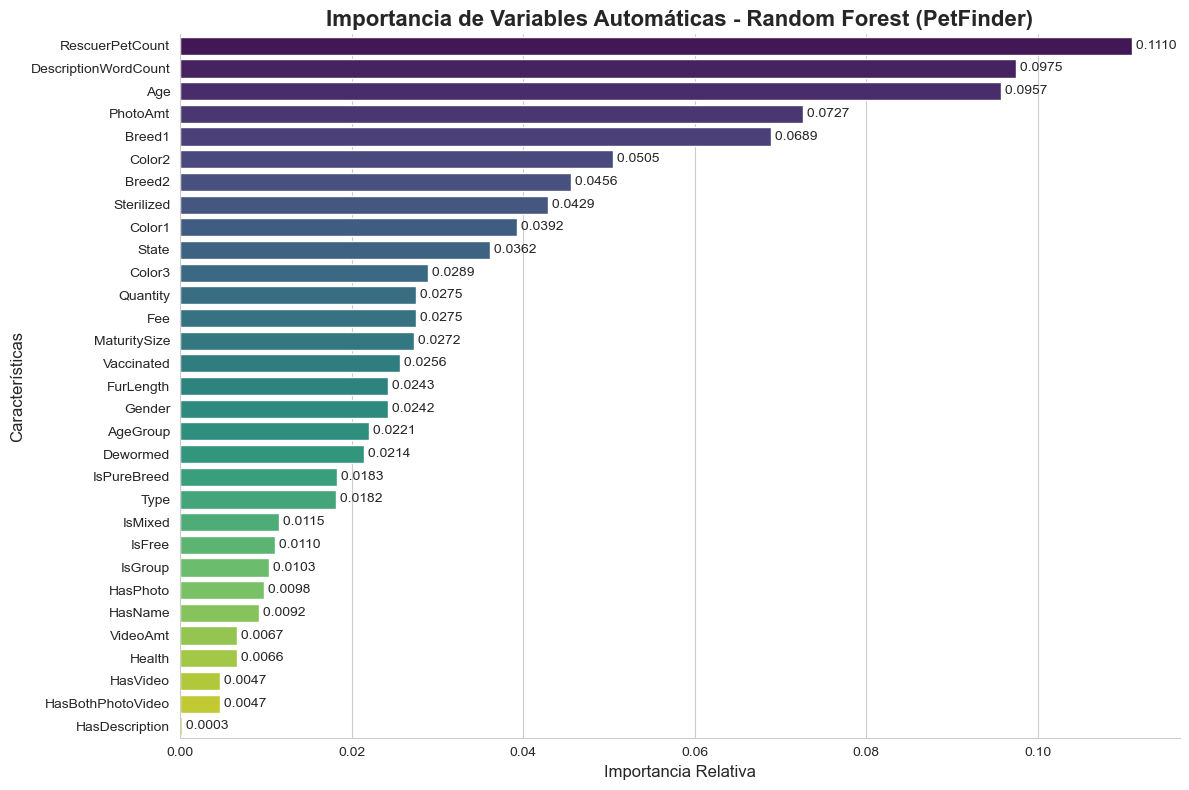

In [47]:
# El modelo Random Forest está dentro del pipeline en el paso 'classifier'
rf_model_inside = rf_pipeline.named_steps['classifier']
importances = rf_model_inside.feature_importances_

# Obtener los nombres de las columnas en el orden exacto en que salieron del preprocesador
feature_names = num_features_limpias + cat_features_limpias

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Ordenar para el gráfico
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Crear la visualización
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Importancia de Variables Automáticas - Random Forest (PetFinder)', fontsize=16, fontweight='bold')
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Características', fontsize=12)

# Añadir valores en las barras
for index, value in enumerate(feature_importance_df['Importance']):
    plt.text(value, index, f' {value:.4f}', va='center', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

In [63]:
df.head(5)

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,...,PhotoAmt,AdoptionSpeed,HasName,IsMixed,HasPhoto,HasVideo,IsFree,IsGroup,PhotoGroup,AgeGroup,IsPureBreed,HasDescription,DescriptionWordCount,RescuerPetCount,HasBothPhotoVideo
0,Gato,Nibble,3,Tabby,NaN,Macho,Black,White,NaN,Pequeño,Corto,No,No,No,Sano,...,1.0,2,True,0,1,0,0,0,1-2 fotos,Puppy/Kitten,1,1,69,8,0
1,Gato,No Name Yet,1,Domestic Medium Hair,NaN,Macho,Black,Brown,NaN,Mediano,Mediano,No sabe,No sabe,No sabe,Sano,...,2.0,0,True,0,1,0,1,0,1-2 fotos,Puppy/Kitten,1,1,23,1,0
2,Perro,Brisco,1,Mixed Breed,NaN,Macho,Brown,White,NaN,Mediano,Mediano,Sí,Sí,No,Sano,...,7.0,3,True,0,1,0,1,0,6+ fotos,Puppy/Kitten,0,1,69,459,0
3,Perro,Miko,4,Mixed Breed,NaN,Hembra,Black,Brown,NaN,Mediano,Corto,Sí,Sí,No,Sano,...,8.0,2,True,0,1,0,0,0,6+ fotos,Puppy/Kitten,0,1,25,50,0
4,Perro,Hunter,1,Mixed Breed,NaN,Macho,Black,NaN,NaN,Mediano,Corto,No,No,No,Sano,...,3.0,2,True,0,1,0,1,0,3-5 fotos,Puppy/Kitten,0,1,81,134,0


### Modelo de prueba LGBM

In [88]:

# ==============================
# LightGBM Model
# ==============================

import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

df_lgbm = df.copy()

In [104]:
# 1. Seleccionar automáticamente columnas numéricas (enteros y decimales)
num_features_lgbm = df_lgbm.select_dtypes(include=[np.number]).columns.tolist()

# 2. Seleccionar automáticamente columnas categóricas (texto o categorías)
cat_features_lgbm = df_lgbm.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas detectadas:", num_features_lgbm)
print("Categóricas detectadas:", cat_features_lgbm)

Numéricas detectadas: ['Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt', 'AdoptionSpeed', 'IsMixed', 'HasPhoto', 'HasVideo', 'IsFree', 'IsGroup', 'IsPureBreed', 'HasDescription', 'DescriptionWordCount', 'RescuerPetCount', 'HasBothPhotoVideo']
Categóricas detectadas: ['Type', 'Name', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State', 'RescuerID', 'Description', 'PetID', 'HasName', 'PhotoGroup', 'AgeGroup']


In [105]:
# 1. Definir lo que NO queremos en el modelo
columnas_target = ['AdoptionSpeed', 'AdoptFast']
columnas_texto_id = ['Name', 'Description', 'RescuerID', 'PetID']
columnas_redundantes = ['TypeLabel', 'VaccinatedLabel', 'DewormedLabel', 'SterilizedLabel', 'HealthLabel', 'FeeGroup', 'PhotoGroup','Health', 'HasDescription','HasPhoto','HasVideo']

eliminar = columnas_target + columnas_texto_id + columnas_redundantes

# 2. Filtrar las listas detectadas automáticamente
num_features_limpias_lgbm = [col for col in num_features_lgbm if col not in eliminar]
cat_features_limpias_lgbm = [col for col in cat_features_lgbm if col not in eliminar]

print("Numéricas listas para el modelo:", num_features_limpias_lgbm)
print("\nCategóricas listas para el modelo:", cat_features_limpias_lgbm)

# 3. Ahora sí, armas tu X y tu y
X_lgbm = df_lgbm[num_features_limpias_lgbm + cat_features_limpias_lgbm]
y_lgbm = df_lgbm['AdoptionSpeed'] # Target

Numéricas listas para el modelo: ['Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt', 'IsMixed', 'IsFree', 'IsGroup', 'IsPureBreed', 'DescriptionWordCount', 'RescuerPetCount', 'HasBothPhotoVideo']

Categóricas listas para el modelo: ['Type', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'State', 'HasName', 'AgeGroup']


In [106]:

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features_limpias_lgbm),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_features_limpias_lgbm)
    ])

# Pipeline con preprocesamiento
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('classifier', LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    ))
])


In [107]:
X_lgbm.head()

,Age,Quantity,Fee,VideoAmt,PhotoAmt,IsMixed,IsFree,IsGroup,IsPureBreed,DescriptionWordCount,RescuerPetCount,HasBothPhotoVideo,Type,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,State,HasName,AgeGroup
0,3,1,100,0,1.0,0,0,0,1,69,8,0,Gato,Tabby,NaN,Macho,Black,White,NaN,Pequeño,Corto,No,No,No,Selangor,True,Puppy/Kitten
1,1,1,0,0,2.0,0,1,0,1,23,1,0,Gato,Domestic Medium Hair,NaN,Macho,Black,Brown,NaN,Mediano,Mediano,No sabe,No sabe,No sabe,Kuala Lumpur,True,Puppy/Kitten
2,1,1,0,0,7.0,0,1,0,0,69,459,0,Perro,Mixed Breed,NaN,Macho,Brown,White,NaN,Mediano,Mediano,Sí,Sí,No,Selangor,True,Puppy/Kitten
3,4,1,150,0,8.0,0,0,0,0,25,50,0,Perro,Mixed Breed,NaN,Hembra,Black,Brown,NaN,Mediano,Corto,Sí,Sí,No,Kuala Lumpur,True,Puppy/Kitten
4,1,1,0,0,3.0,0,1,0,0,81,134,0,Perro,Mixed Breed,NaN,Macho,Black,NaN,NaN,Mediano,Corto,No,No,No,Selangor,True,Puppy/Kitten


In [108]:
# 6. Split de datos
import random 

random.seed(42)
np.random.seed(42)
X_train, X_val, y_train, y_val = train_test_split(X_lgbm, y_lgbm, test_size=0.2, random_state=42, stratify=y)


# Entrenar
print("Entrenando LightGBM...")
lgbm_pipeline.fit(X_train, y_train)

# Predecir
y_pred_lgbm = lgbm_pipeline.predict(X_val)

# Evaluar
accuracy_lgbm = accuracy_score(y_val, y_pred_lgbm)
print("Accuracy LGBM:", accuracy_lgbm)

# Quadratic Weighted Kappa
qwk_lgbm = cohen_kappa_score(y_val, y_pred_lgbm, weights='quadratic')
print(f"Quadratic Weighted Kappa: {qwk_lgbm:.4f}")


Entrenando LightGBM...


c:\Users\Patricia\anaconda3\envs\ldi2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy LGBM: 0.43347782594198064
Quadratic Weighted Kappa: 0.3639


C:\Users\Patricia\AppData\Local\Temp\ipykernel_8772\3586336439.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_lgbm, palette='viridis')


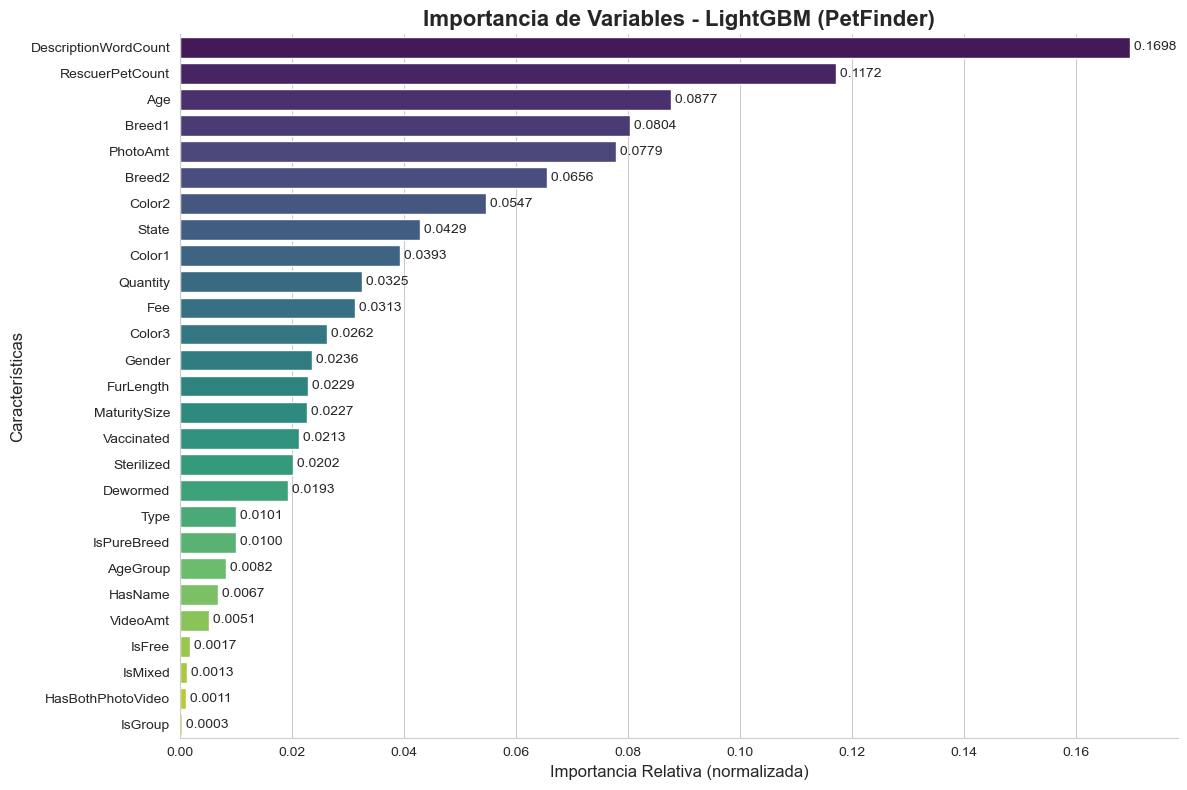

In [ ]:

# Feature importance (del modelo dentro del pipeline)
lgbm_model = lgbm_pipeline.named_steps['classifier']
importances = lgbm_model.feature_importances_

# Normalizar para que sume 1 (como RF)
importances_normalized = importances / importances.sum()

# Obtener los nombres de las columnas en el orden exacto en que salieron del preprocesador
feature_names_lgbm = num_features_limpias_lgbm + cat_features_limpias_lgbm

# Crear DataFrame con la importancia normalizada
feature_importance_lgbm = pd.DataFrame({
    'Feature': feature_names_lgbm,
    'Importance': importances_normalized
}).sort_values(by='Importance', ascending=False)

# Visualización con todas las columnas
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_lgbm, palette='viridis')

plt.title('Importancia de Variables - LightGBM (PetFinder)', fontsize=16, fontweight='bold')
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Características', fontsize=12)

# Añadir valores en las barras
for index, value in enumerate(feature_importance_lgbm['Importance']):
    plt.text(value, index, f' {value:.4f}', va='center', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()


### Modelo muy basico SVM

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import cohen_kappa_score, classification_report

In [49]:
# 4. Selección de variables
# Definimos cuáles son numéricas y cuáles categóricas para el preprocesamiento
num_features = ['Age', 'Fee', 'VideoAmt', 'PhotoAmt', 'DescriptionWordCount', 'RescuerPetCount', 'Quantity']
cat_features = ['Type', 'Breed1', 'Gender', 'Color1', 'MaturitySize', 'FurLength', 'Vaccinated', 'Sterilized', 'Health', 'AgeGroup']

X = df[num_features + cat_features].copy()
y = df['AdoptionSpeed']

# 5. Pipeline de Preprocesamiento (CRÍTICO para SVM)
# SVM requiere que los datos numéricos estén en la misma escala (media 0, var 1)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# 6. Definición del Pipeline con el Modelo SVM
# Usamos kernel='rbf' por defecto, que maneja relaciones no lineales
svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

# 7. Split y Entrenamiento
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [50]:

print("Entrenando SVM...")
svm_model.fit(X_train, y_train)

# 8. Evaluación
preds = svm_model.predict(X_val)
qwk = cohen_kappa_score(y_val, preds, weights='quadratic')

print(f"\n--- Resultados del Modelo SVM ---")
print(f"Quadratic Weighted Kappa: {qwk:.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_val, preds))

Entrenando SVM...

--- Resultados del Modelo SVM ---
Quadratic Weighted Kappa: 0.3018

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        82
           1       0.33      0.28      0.30       618
           2       0.33      0.44      0.38       807
           3       0.46      0.14      0.21       652
           4       0.47      0.69      0.56       840

    accuracy                           0.40      2999
   macro avg       0.32      0.31      0.29      2999
weighted avg       0.39      0.40      0.37      2999



c:\Users\Patricia\anaconda3\envs\ldi2\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Patricia\anaconda3\envs\ldi2\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Patricia\anaconda3\envs\ldi2\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

#### Gráfico de feature importance - puede demorar

Calculando importancia por permutación (puede tomar unos segundos)...


C:\Users\Patricia\AppData\Local\Temp\ipykernel_8772\1941887947.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=perm_importance_df, palette='mako')


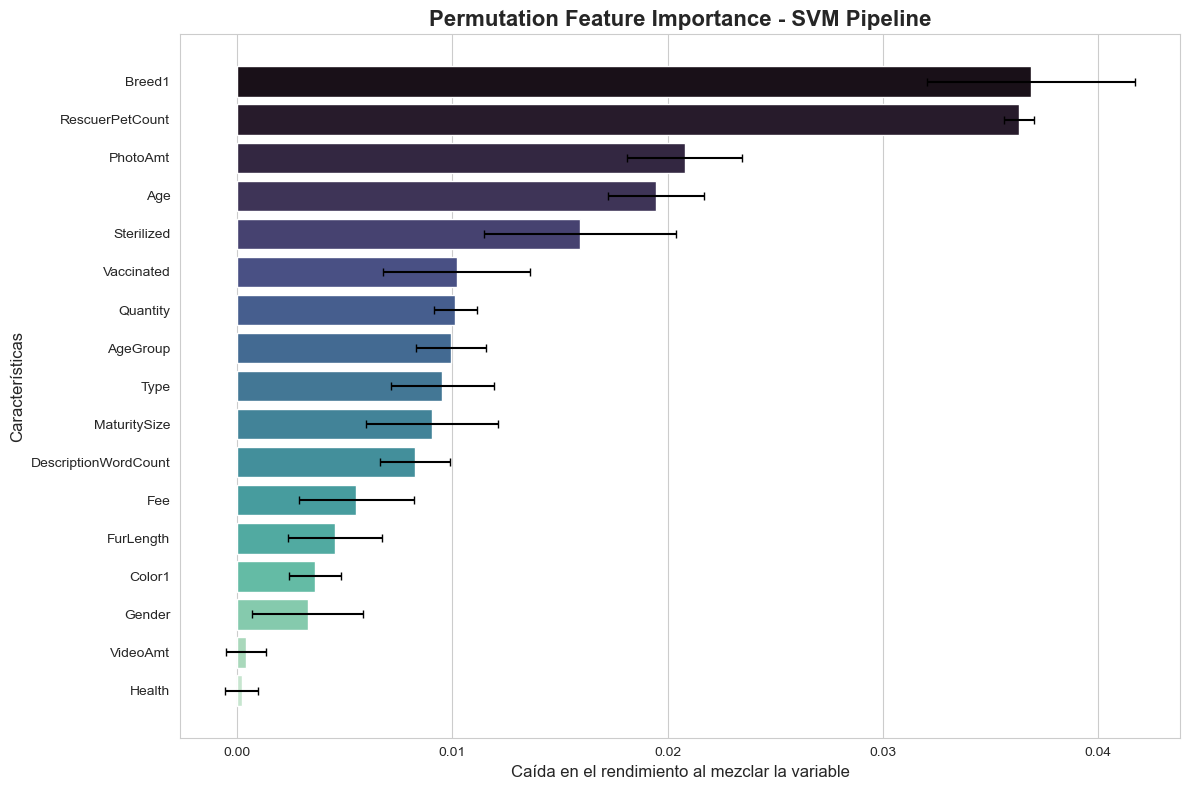

In [51]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Asumiendo que tu pipeline SVM ya está entrenado bajo la variable 'svm_model'
# Usamos X_val y y_val para ver la importancia en datos no vistos (mejor práctica)

print("Calculando importancia por permutación (puede tomar unos segundos)...")
resultado_perm = permutation_importance(
    svm_model, X_val, y_val,
    n_repeats=5,        # Cuántas veces mezcla cada variable
    random_state=42,
    n_jobs=-1,          # Usa todos los procesadores
    scoring='accuracy'  # Puedes cambiarlo a tu métrica preferida
)

# Crear DataFrame con los resultados medios
perm_importance_df = pd.DataFrame({
    'Feature': X_val.columns,
    'Importance': resultado_perm.importances_mean,
    'Std_dev': resultado_perm.importances_std # Desviación estándar de las repeticiones
})

# Ordenar de mayor a menor
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=False)

# Visualización
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=perm_importance_df, palette='mako')

# Añadir barras de error (desviación estándar) para ver la estabilidad
plt.errorbar(x=perm_importance_df['Importance'], y=range(len(perm_importance_df)),
             xerr=perm_importance_df['Std_dev'], fmt='none', c='black', capsize=3)

plt.title('Permutation Feature Importance - SVM Pipeline', fontsize=16, fontweight='bold')
plt.xlabel('Caída en el rendimiento al mezclar la variable', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.tight_layout()
plt.show()

Esta técnica funciona así: toma una variable (ej. Age), mezcla sus valores al azar y mide qué tanto empeora el modelo. Si el modelo empeora mucho, la variable era muy importante.